# SETUP DAN IMPORT LIBRARIES

In [ ]:
# Import semua library yang diperlukan untuk analisis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*80)
print("INTEGRASI RANDOM FOREST DAN ASSOCIATION RULE MINING")
print("UNTUK PREDIKSI DAN POLA RISIKO PENYAKIT JANTUNG")
print("="*80)
print("\n✓ Libraries imported successfully!")

INTEGRASI RANDOM FOREST DAN ASSOCIATION RULE MINING
UNTUK PREDIKSI DAN POLA RISIKO PENYAKIT JANTUNG

✓ Libraries imported successfully!


## Load Dataset

In [ ]:
# Download dan load dataset Heart Failure Prediction dari Kaggle

print("LOADING DATASET..")

# Install kagglehub
!pip install -q kagglehub

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print(f"\n✓ Dataset downloaded to: {path}")

# List dan load file CSV
files_in_path = os.listdir(path)
csv_file = [f for f in files_in_path if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"\n✓ Dataset loaded successfully!")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Features: {df.shape[1]-1} predictors + 1 target variable")

LOADING DATASET..
Using Colab cache for faster access to the 'heart-failure-prediction' dataset.

✓ Dataset downloaded to: /kaggle/input/heart-failure-prediction

✓ Dataset loaded successfully!
  Shape: 918 rows × 12 columns
  Features: 11 predictors + 1 target variable


# DATA UNDERSTANDING & EXPLORATORY DATA ANALYSIS (EDA)

## 1.1 OVERVIEW DATASET

In [ ]:
# Menampilkan informasi dasar tentang dataset
print("1. DATA UNDERSTANDING & EXPLORATORY DATA ANALYSIS")
print("\n--- 1.1 Dataset Overview ---")
print("\nFirst 5 rows:")
display(df.head())

print("\n\nDataset Information:")
print(df.info())

print("\n\nDescriptive Statistics:")
display(df.describe())

# Tampilkan nama kolom dan tipe data
print("\n\nColumn Names and Data Types:")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

1. DATA UNDERSTANDING & EXPLORATORY DATA ANALYSIS

--- 1.1 Dataset Overview ---

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


Descriptive Statistics:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000




Column Names and Data Types:
  - Age: int64
  - Sex: object
  - ChestPainType: object
  - RestingBP: int64
  - Cholesterol: int64
  - FastingBS: int64
  - RestingECG: object
  - MaxHR: int64
  - ExerciseAngina: object
  - Oldpeak: float64
  - ST_Slope: object
  - HeartDisease: int64


## 1.2 Data Quality Check

In [ ]:
# Memeriksa missing values, duplikat, dan nilai tidak valid

print("\n--- 1.2 Data Quality Check ---")

# Cek missing values
print("\n📌 Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✓ No missing values detected")

# Cek duplikat
duplicates = df.duplicated().sum()
print(f"\n📌 Duplicate Rows: {duplicates}")
if duplicates > 0:
    print(f"  ⚠️ Warning: {duplicates} duplicate rows found")
else:
    print("  ✓ No duplicates")

# Cek nilai Cholesterol = 0 (nilai tidak valid)
print("\n📌 Invalid Values Check (Cholesterol = 0):")
cholesterol_zero = (df['Cholesterol'] == 0).sum()
print(f"  Cholesterol = 0: {cholesterol_zero} rows ({cholesterol_zero/len(df)*100:.2f}%)")
if cholesterol_zero > 0:
    print(f"  ⚠️ These values will be handled in data preparation")

# Cek nilai RestingBP = 0
restingbp_zero = (df['RestingBP'] == 0).sum()
print(f"  RestingBP = 0: {restingbp_zero} rows ({restingbp_zero/len(df)*100:.2f}%)")


--- 1.2 Data Quality Check ---

📌 Missing Values:
✓ No missing values detected

📌 Duplicate Rows: 0
  ✓ No duplicates

📌 Invalid Values Check (Cholesterol = 0):
  Cholesterol = 0: 172 rows (18.74%)
  ⚠️ These values will be handled in data preparation
  RestingBP = 0: 1 rows (0.11%)


## 1.3 ANALISIS VARIABEL TARGET


--- 1.3 Target Variable Analysis ---

Heart Disease Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Class Balance:
  No Disease (0): 410 (44.7%)
  Disease (1): 508 (55.3%)

  Imbalance Ratio: 0.81:1
  ✓ Dataset relatively balanced


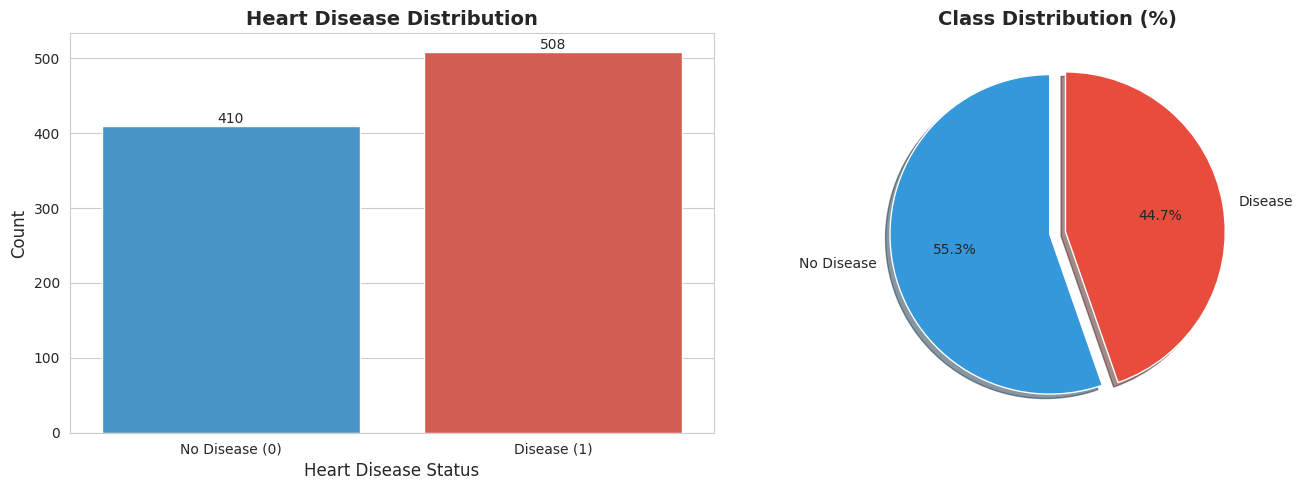

In [ ]:
# Menganalisis distribusi target variable (HeartDisease)

print("\n--- 1.3 Target Variable Analysis ---")

# Hitung distribusi kelas
target_dist = df['HeartDisease'].value_counts()
print("\nHeart Disease Distribution:")
print(target_dist)
print(f"\nClass Balance:")
print(f"  No Disease (0): {target_dist[0]} ({target_dist[0]/len(df)*100:.1f}%)")
print(f"  Disease (1): {target_dist[1]} ({target_dist[1]/len(df)*100:.1f}%)")

# Hitung rasio imbalance
imbalance_ratio = target_dist[0] / target_dist[1]
print(f"\n  Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 1.5:
    print(f"  ⚠️ Dataset slightly imbalanced (consider stratified sampling)")
else:
    print(f"  ✓ Dataset relatively balanced")

# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='HeartDisease', ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])

# Tambahkan value labels pada bar
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart
colors = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)
target_dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                 labels=['No Disease', 'Disease'], colors=colors,
                 explode=explode, shadow=True, startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 1.4 ANALISIS FITUR NUMERIK


--- 1.4 Numerical Features Analysis ---

Descriptive Statistics for Numerical Features:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


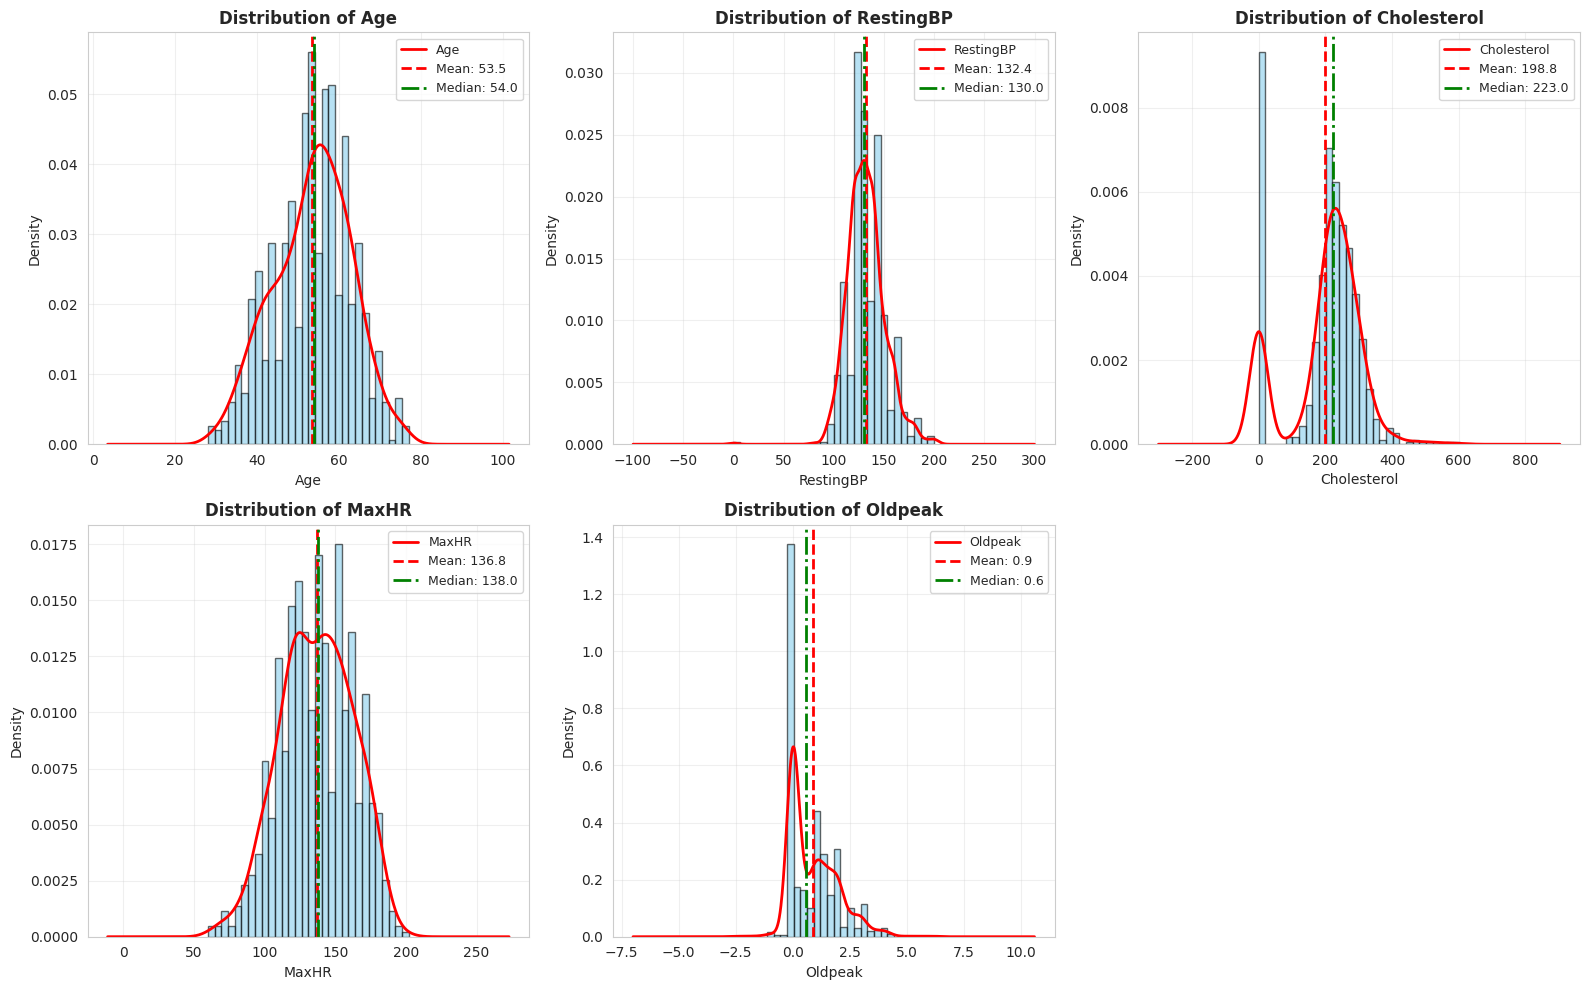


📌 Outlier Detection (IQR Method):
  Age: 0 outliers (0.00%)
  RestingBP: 28 outliers (3.05%)
  Cholesterol: 183 outliers (19.93%)
  MaxHR: 2 outliers (0.22%)
  Oldpeak: 16 outliers (1.74%)


In [ ]:
# Menganalisis distribusi fitur-fitur numerik

print("\n--- 1.4 Numerical Features Analysis ---")

# Definisikan kolom numerik
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Statistik deskriptif untuk fitur numerik
print("\nDescriptive Statistics for Numerical Features:")
display(df[numerical_cols].describe())

# Visualisasi distribusi
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Histogram dengan KDE
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.6, color='skyblue', density=True)

    # Tambahkan KDE (Kernel Density Estimation)
    df[col].plot(kind='kde', ax=axes[idx], color='red', linewidth=2, secondary_y=False)

    # Statistik
    mean_val = df[col].mean()
    median_val = df[col].median()

    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median: {median_val:.1f}')

    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Density', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

# Hapus subplot kosong
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Deteksi outliers menggunakan IQR
print("\n📌 Outlier Detection (IQR Method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

## 1.5 ANALISIS FITUR KATEGORIKAL


--- 1.5 Categorical Features Analysis ---

Value Counts for Categorical Features:

Sex:
Sex
M    725
F    193
Name: count, dtype: int64
  Unique values: 2

ChestPainType:
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
  Unique values: 4

RestingECG:
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
  Unique values: 3

ExerciseAngina:
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
  Unique values: 2

ST_Slope:
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
  Unique values: 3

FastingBS:
FastingBS
0    704
1    214
Name: count, dtype: int64
  Unique values: 2


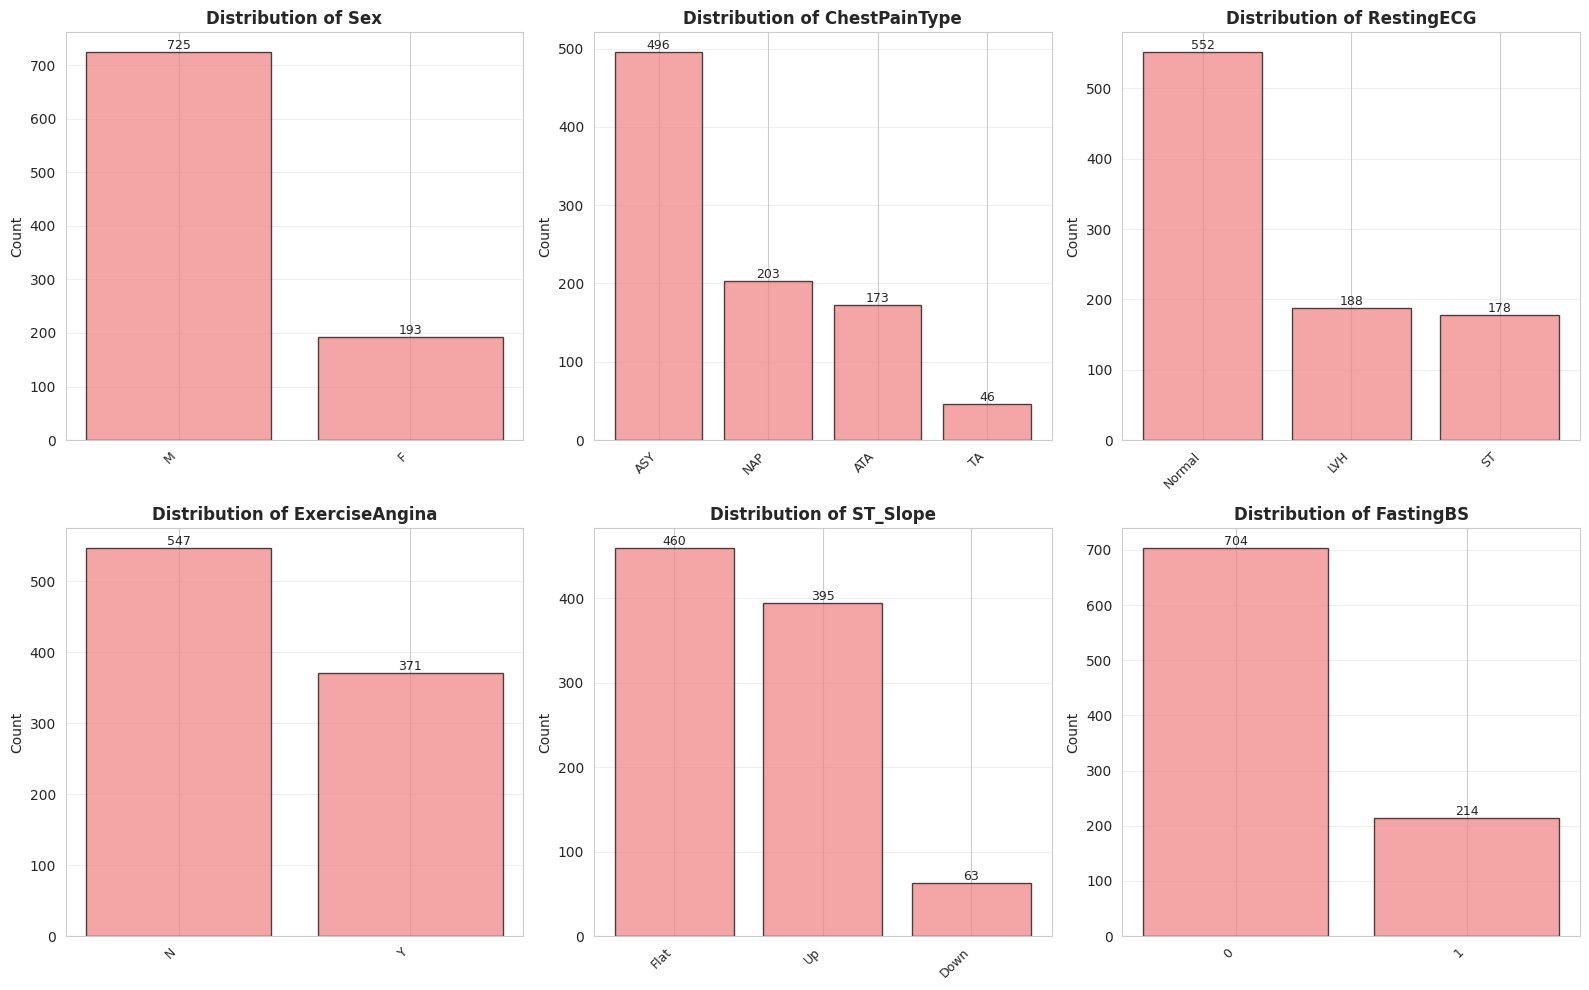

In [ ]:
# Menganalisis distribusi fitur-fitur kategorikal

print("\n--- 1.5 Categorical Features Analysis ---")

# Definisikan kolom kategorikal
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

# Tampilkan value counts untuk setiap fitur kategorikal
print("\nValue Counts for Categorical Features:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"  Unique values: {df[col].nunique()}")

# Visualisasi distribusi kategorikal
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()

    # Bar plot
    axes[idx].bar(range(len(value_counts)), value_counts.values,
                  color='lightcoral', alpha=0.7, edgecolor='black')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Tambahkan value labels
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 1.6 ANALISIS KORELASI


--- 1.6 Correlation Analysis ---

Correlation with Heart Disease (sorted by absolute value):
HeartDisease      1.000000
ExerciseAngina    0.494282
Oldpeak           0.403951
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.107589
RestingECG        0.057384
Cholesterol      -0.232741
ChestPainType    -0.386828
MaxHR            -0.400421
ST_Slope         -0.558771
Name: HeartDisease, dtype: float64

📌 Features with Strong Correlation (|r| > 0.3):
  ExerciseAngina: 0.494
  Oldpeak: 0.404
  Sex: 0.305
  ChestPainType: -0.387
  MaxHR: -0.400
  ST_Slope: -0.559


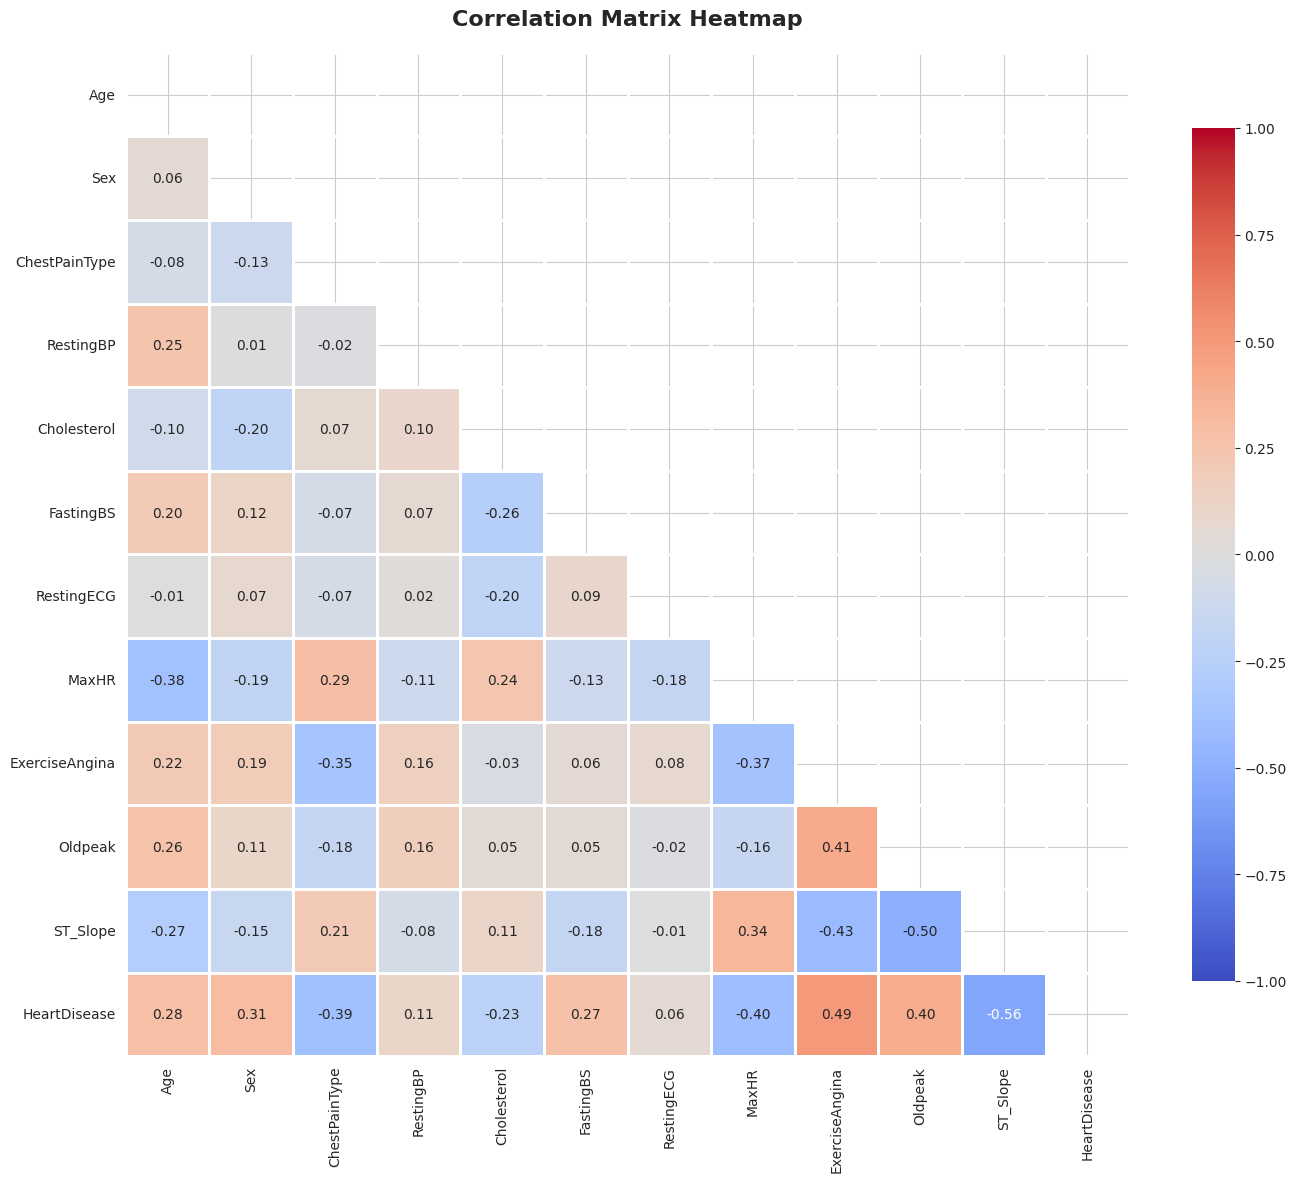

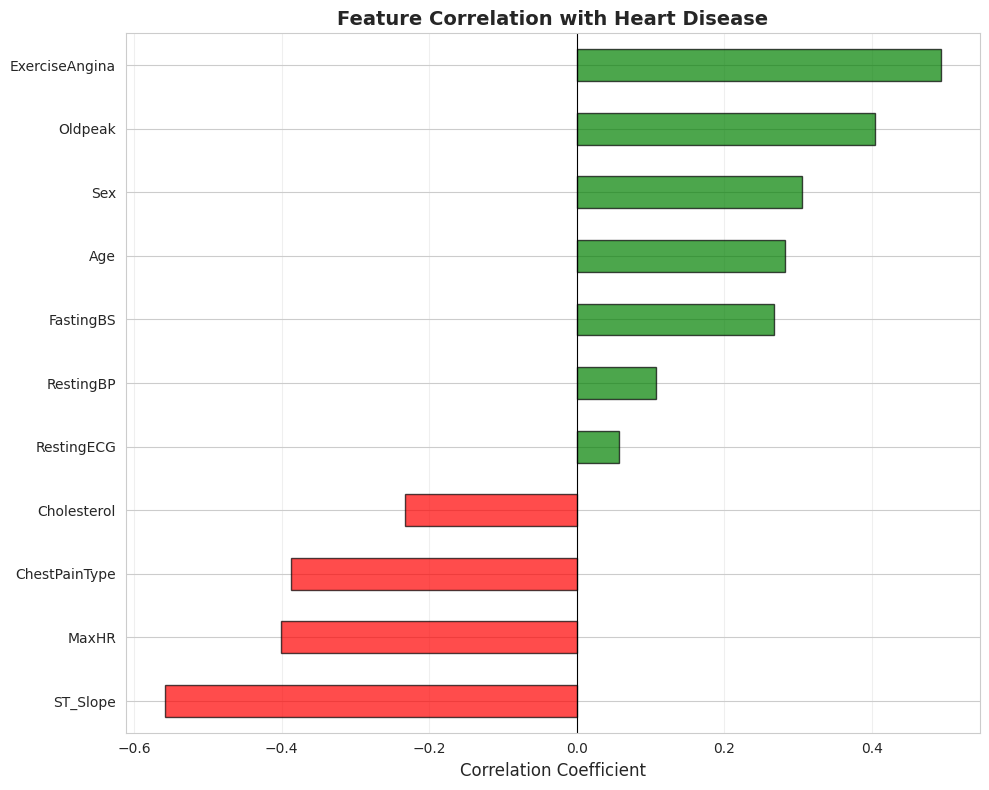

In [ ]:
# Menganalisis korelasi antar fitur dan dengan target variable

print("\n--- 1.6 Correlation Analysis ---")

# Siapkan data untuk korelasi (encode kategorikal terlebih dahulu)
df_corr = df.copy()
le = LabelEncoder()

# Encode semua fitur kategorikal
for col in categorical_cols:
    if df_corr[col].dtype == 'object':
        df_corr[col] = le.fit_transform(df_corr[col])

# Hitung matriks korelasi
correlation = df_corr.corr()

# Tampilkan korelasi dengan target variable
print("\nCorrelation with Heart Disease (sorted by absolute value):")
target_corr = correlation['HeartDisease'].sort_values(ascending=False)
print(target_corr)

# Identifikasi fitur dengan korelasi kuat
print("\n📌 Features with Strong Correlation (|r| > 0.3):")
strong_corr = target_corr[abs(target_corr) > 0.3]
for feature, corr_value in strong_corr.items():
    if feature != 'HeartDisease':
        print(f"  {feature}: {corr_value:.3f}")

# Visualisasi: Heatmap korelasi
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation, dtype=bool))  # Mask untuk upper triangle
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Visualisasi: Bar plot korelasi dengan target
plt.figure(figsize=(10, 8))
target_corr_sorted = target_corr.drop('HeartDisease').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr_sorted.values]
target_corr_sorted.plot(kind='barh', color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Feature Correlation with Heart Disease', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 1.7 ANALISIS BIVARIAT


--- 1.7 Bivariate Analysis (Features vs Target) ---

📌 Numerical Features vs Heart Disease:


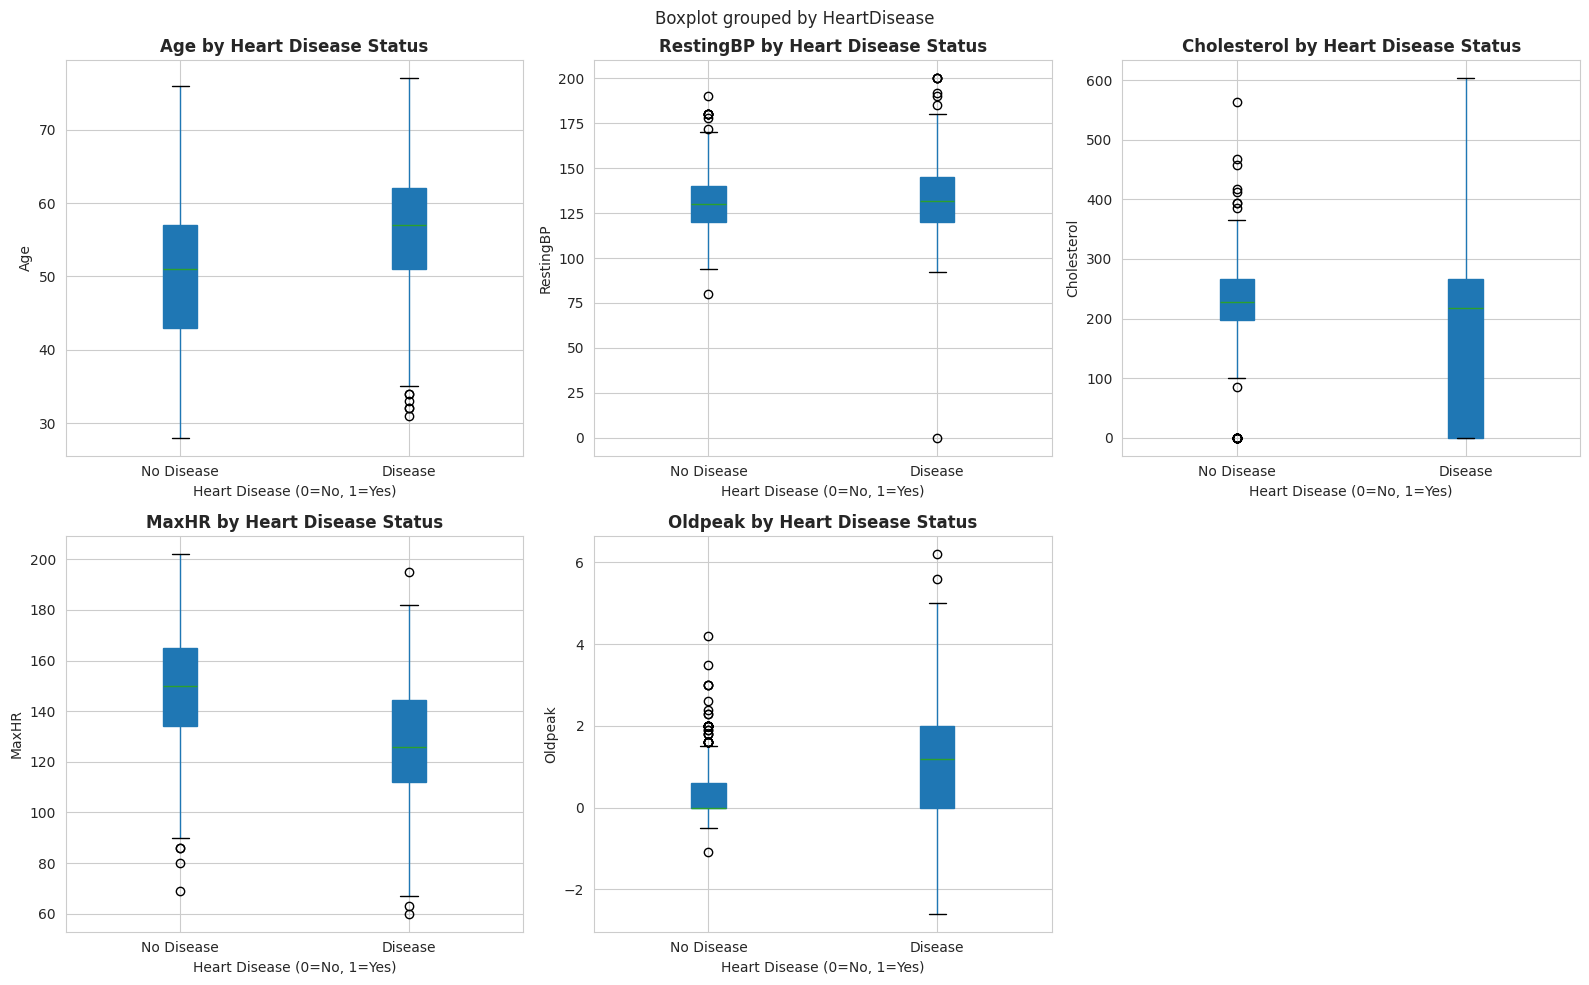


📌 Categorical Features vs Heart Disease:


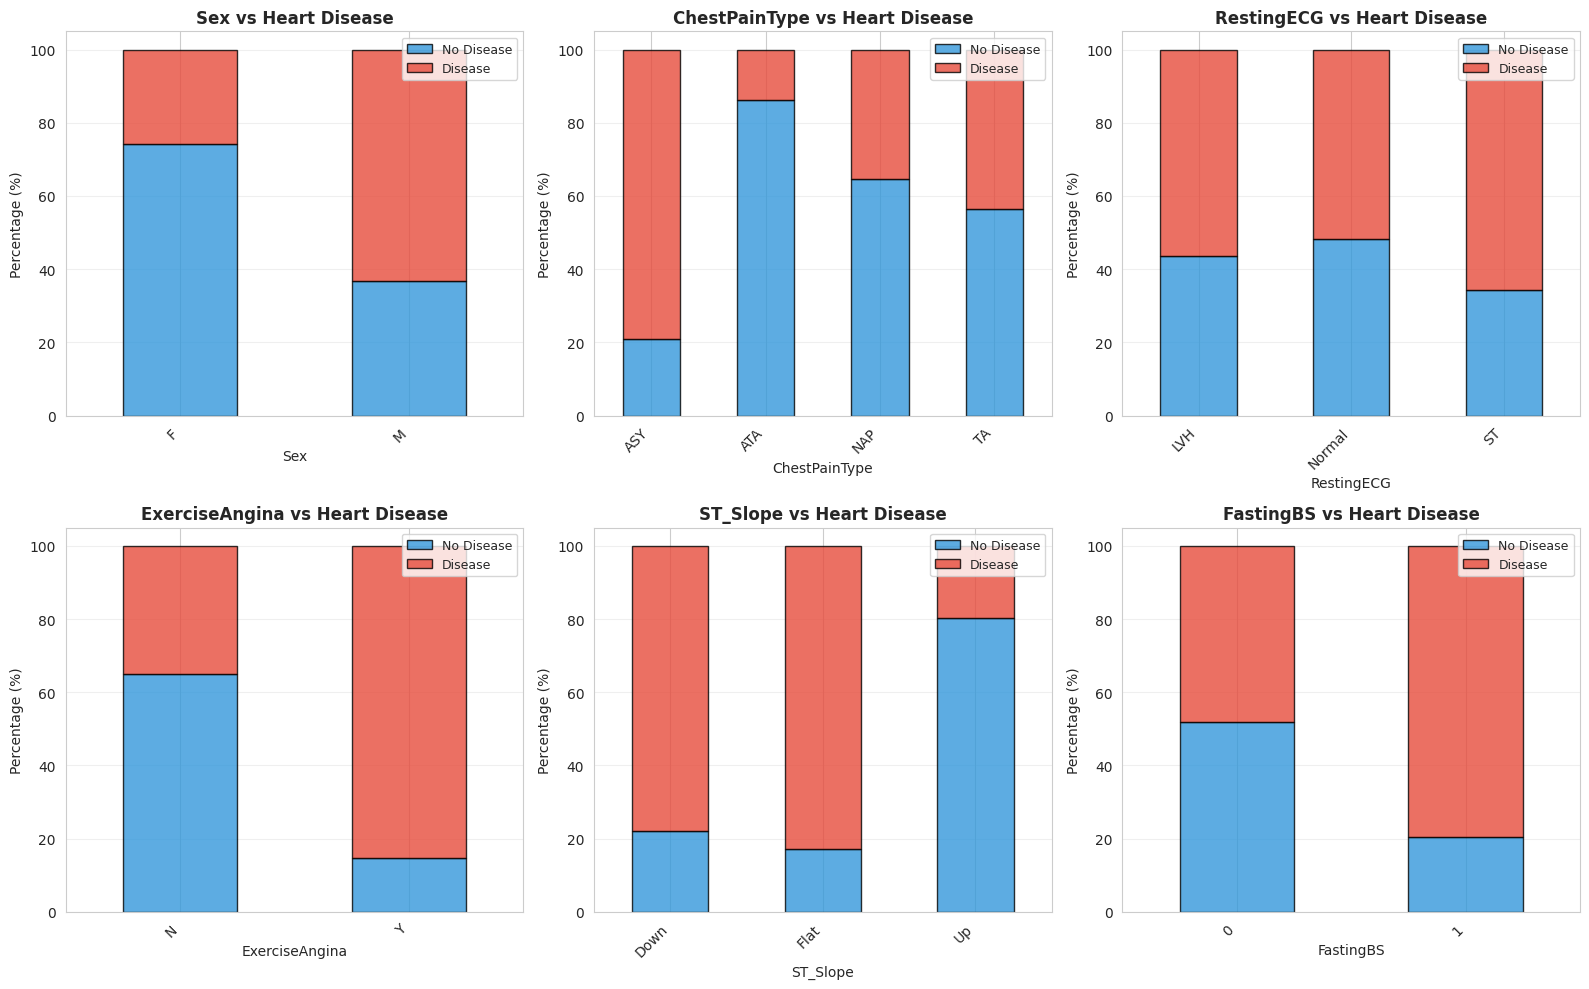


✓ Data Understanding & EDA completed!


In [ ]:
# Menganalisis hubungan antara fitur dengan target variable

print("\n--- 1.7 Bivariate Analysis (Features vs Target) ---")

# Analisis fitur numerik vs target
print("\n📌 Numerical Features vs Heart Disease:")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Box plot untuk membandingkan distribusi berdasarkan target
    df.boxplot(column=col, by='HeartDisease', ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'{col} by Heart Disease Status', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Heart Disease (0=No, 1=Yes)', fontsize=10)
    axes[idx].set_ylabel(col, fontsize=10)
    plt.sca(axes[idx])
    plt.xticks([1, 2], ['No Disease', 'Disease'])

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Analisis fitur kategorikal vs target
print("\n📌 Categorical Features vs Heart Disease:")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    # Crosstab dan stacked bar plot
    ct = pd.crosstab(df[col], df['HeartDisease'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx],
            color=['#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')
    axes[idx].set_title(f'{col} vs Heart Disease', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(['No Disease', 'Disease'], fontsize=9)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Data Understanding & EDA completed!")

# DATA PREPARATION & PREPROCESSING (KLASIFIKASI)

## 2.1 MENANGANI MISSING VALUES DAN NILAI TIDAK VALID

In [ ]:
# Membersihkan data dari missing values dan nilai tidak valid

print("\n" + "="*80)
print("2. DATA PREPARATION & PREPROCESSING (FOR CLASSIFICATION)")
print("="*80)

print("\n--- 2.1 Handling Missing & Invalid Values ---")

# Copy dataset untuk preprocessing
df_processed = df.copy()

# Handle Cholesterol = 0 (nilai tidak valid)
print("\n📌 Handling Invalid Cholesterol Values:")
cholesterol_zero_count = (df_processed['Cholesterol'] == 0).sum()
print(f"  Cholesterol = 0: {cholesterol_zero_count} rows")

if cholesterol_zero_count > 0:
    # Replace 0 dengan NaN
    df_processed['Cholesterol'] = df_processed['Cholesterol'].replace(0, np.nan)

    # Fill dengan median berdasarkan grup Sex dan HeartDisease
    df_processed['Cholesterol'] = df_processed.groupby(['Sex', 'HeartDisease'])['Cholesterol'].transform(
        lambda x: x.fillna(x.median())
    )

    print(f"  ✓ Filled with grouped median (by Sex & HeartDisease)")
    print(f"  Remaining NaN: {df_processed['Cholesterol'].isnull().sum()}")

# Handle RestingBP = 0 (jika ada)
restingbp_zero = (df_processed['RestingBP'] == 0).sum()
if restingbp_zero > 0:
    print(f"\n📌 Handling Invalid RestingBP Values:")
    print(f"  RestingBP = 0: {restingbp_zero} rows")
    df_processed['RestingBP'] = df_processed['RestingBP'].replace(0, np.nan)
    df_processed['RestingBP'] = df_processed.groupby(['Sex', 'HeartDisease'])['RestingBP'].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"  ✓ Filled with grouped median")

print("\n✓ Invalid values handled successfully!")


2. DATA PREPARATION & PREPROCESSING (FOR CLASSIFICATION)

--- 2.1 Handling Missing & Invalid Values ---

📌 Handling Invalid Cholesterol Values:
  Cholesterol = 0: 172 rows
  ✓ Filled with grouped median (by Sex & HeartDisease)
  Remaining NaN: 0

📌 Handling Invalid RestingBP Values:
  RestingBP = 0: 1 rows
  ✓ Filled with grouped median

✓ Invalid values handled successfully!


## 2.2 MENANGANI OUTLIERS


--- 2.2 Handling Outliers (IQR Method) ---

📌 Outlier Treatment Summary:
------------------------------------------------------------
  RestingBP:
    - Outliers capped: 27
    - Bounds: [90.00, 170.00]
  Cholesterol:
    - Outliers capped: 38
    - Bounds: [131.50, 351.50]
  MaxHR:
    - Outliers capped: 2
    - Bounds: [66.00, 210.00]
  Oldpeak:
    - Outliers capped: 16
    - Bounds: [-2.25, 3.75]


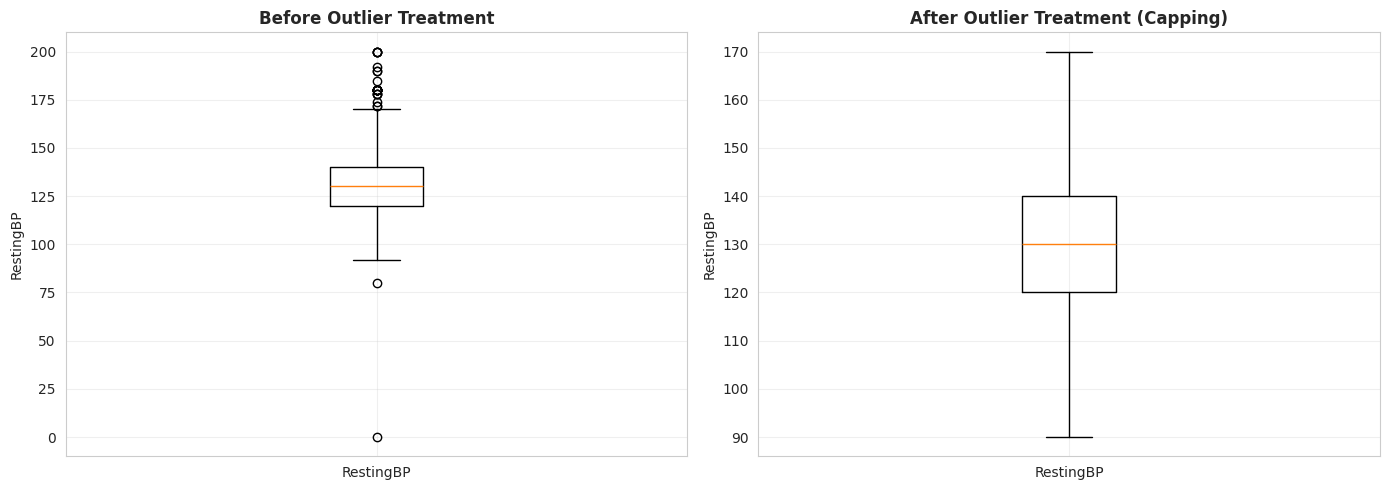


✓ Outliers handled successfully!


In [ ]:
# Menangani outliers menggunakan metode IQR (capping)

print("\n--- 2.2 Handling Outliers (IQR Method) ---")

def cap_outliers(df, column):
    """
    Cap outliers menggunakan metode IQR
    Outliers di-cap pada batas lower dan upper bound
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Hitung jumlah outliers
    outliers_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    # Capping outliers
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

    return df, outliers_count, lower_bound, upper_bound

print("\n📌 Outlier Treatment Summary:")
print("-" * 60)

outliers_summary = []
for col in ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']:
    df_processed, count, lower, upper = cap_outliers(df_processed, col)
    outliers_summary.append({
        'Feature': col,
        'Outliers': count,
        'Lower Bound': f'{lower:.2f}',
        'Upper Bound': f'{upper:.2f}'
    })
    print(f"  {col}:")
    print(f"    - Outliers capped: {count}")
    print(f"    - Bounds: [{lower:.2f}, {upper:.2f}]")

# Visualisasi: Before & After (contoh untuk RestingBP)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([df['RestingBP']], labels=['RestingBP'])
axes[0].set_title('Before Outlier Treatment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RestingBP', fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([df_processed['RestingBP']], labels=['RestingBP'])
axes[1].set_title('After Outlier Treatment (Capping)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RestingBP', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Outliers handled successfully!")

## 2.3 FEATURE ENGINEERING


--- 2.3 Feature Engineering ---

📌 Creating New Categorical Features:
  ✓ Age_Group: Young (<40), Middle (40-60), Senior (>60)
  ✓ BP_Category: Normal, Prehypertension, Stage1_HTN, Stage2_HTN
  ✓ Cholesterol_Category: Desirable (<200), Borderline (200-240), High (>240)
  ✓ MaxHR_Category: Low (<120), Medium (120-150), High (>150)
  ✓ Oldpeak_Category: No_Depression, Mild, Moderate, Severe


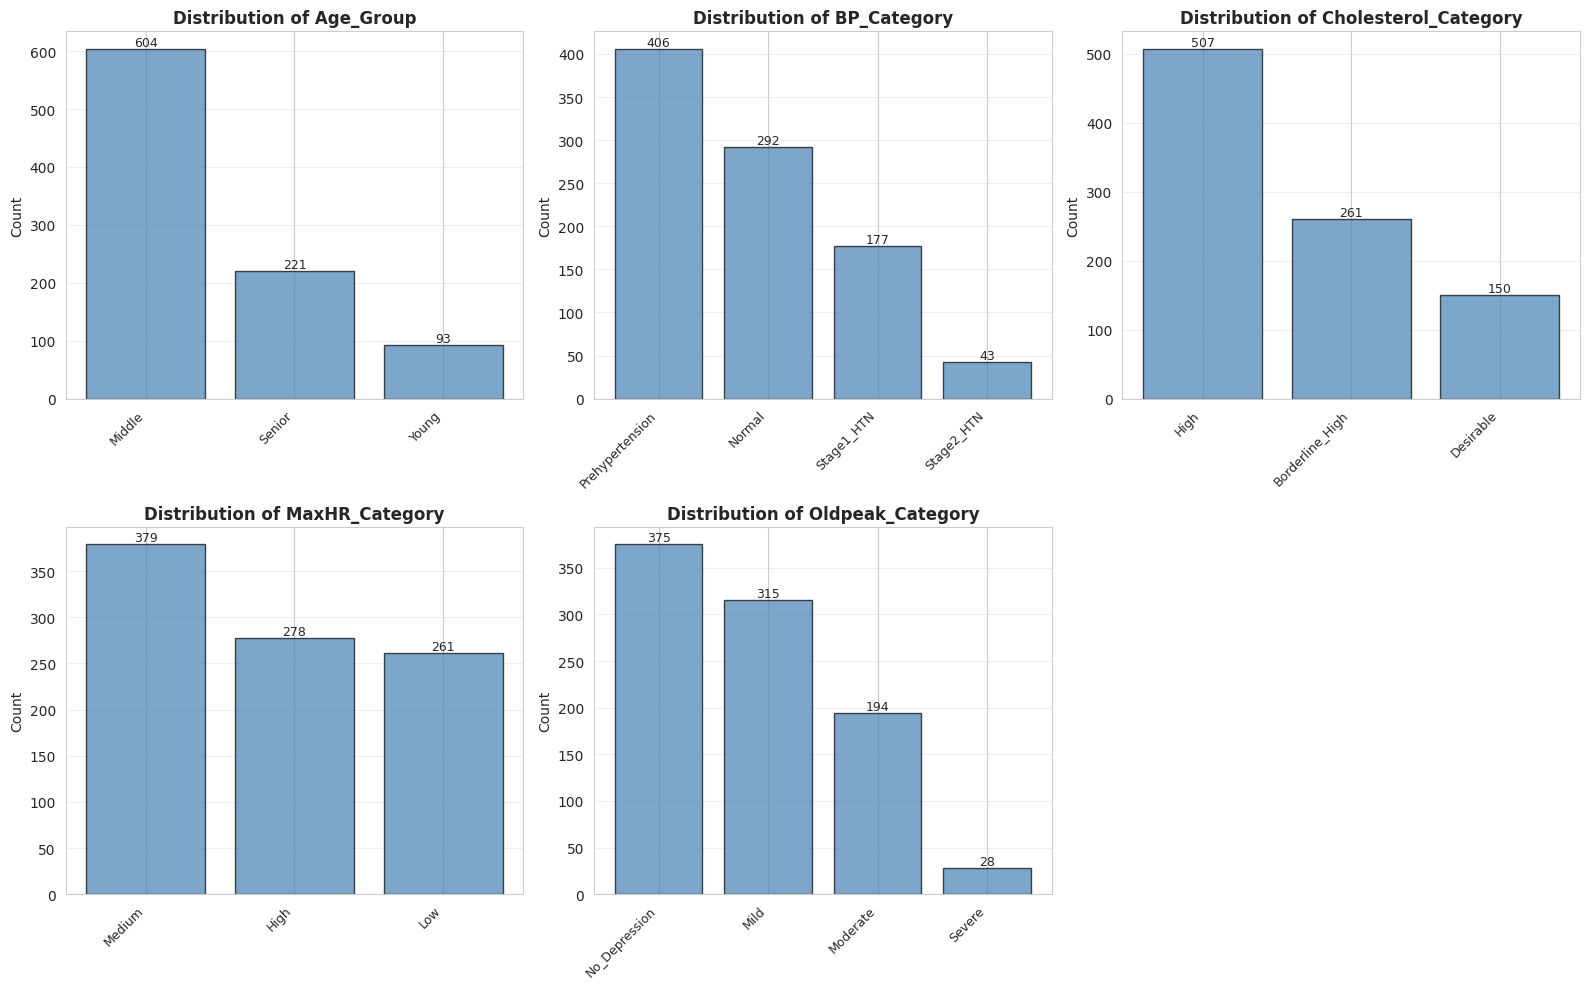


✓ Feature engineering completed!
  Total features now: 17


In [ ]:
# Membuat fitur baru dari fitur yang sudah ada

print("\n--- 2.3 Feature Engineering ---")

print("\n📌 Creating New Categorical Features:")

# 1. Age Groups (berdasarkan kategori usia medis)
df_processed['Age_Group'] = pd.cut(df_processed['Age'],
                                    bins=[0, 40, 60, 100],
                                    labels=['Young', 'Middle', 'Senior'])
print("  ✓ Age_Group: Young (<40), Middle (40-60), Senior (>60)")

# 2. BP Category (berdasarkan AHA guidelines)
df_processed['BP_Category'] = pd.cut(df_processed['RestingBP'],
                                      bins=[0, 120, 140, 160, 200],
                                      labels=['Normal', 'Prehypertension',
                                              'Stage1_HTN', 'Stage2_HTN'])
print("  ✓ BP_Category: Normal, Prehypertension, Stage1_HTN, Stage2_HTN")

# 3. Cholesterol Category (berdasarkan NCEP guidelines)
df_processed['Cholesterol_Category'] = pd.cut(df_processed['Cholesterol'],
                                               bins=[0, 200, 240, 400],
                                               labels=['Desirable', 'Borderline_High', 'High'])
print("  ✓ Cholesterol_Category: Desirable (<200), Borderline (200-240), High (>240)")

# 4. MaxHR Category
df_processed['MaxHR_Category'] = pd.cut(df_processed['MaxHR'],
                                         bins=[0, 120, 150, 250],
                                         labels=['Low', 'Medium', 'High'])
print("  ✓ MaxHR_Category: Low (<120), Medium (120-150), High (>150)")

# 5. Oldpeak Category (ST depression severity)
df_processed['Oldpeak_Category'] = pd.cut(df_processed['Oldpeak'],
                                           bins=[-1, 0, 1.5, 3.0, 10],
                                           labels=['No_Depression', 'Mild',
                                                   'Moderate', 'Severe'])
print("  ✓ Oldpeak_Category: No_Depression, Mild, Moderate, Severe")

# Visualisasi distribusi fitur baru
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

new_features = ['Age_Group', 'BP_Category', 'Cholesterol_Category',
                'MaxHR_Category', 'Oldpeak_Category']

for idx, col in enumerate(new_features):
    value_counts = df_processed[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values,
                  color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Tambahkan value labels
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Feature engineering completed!")
print(f"  Total features now: {df_processed.shape[1]}")

## 2.4 ENCODING VARIABEL KATEGORIKAL

In [ ]:
# Mengubah variabel kategorikal menjadi numerik

print("\n--- 2.4 Encoding Categorical Variables ---")

# Label Encoding untuk variabel binary
print("\n📌 Label Encoding (Binary Variables):")
le = LabelEncoder()

df_processed['Sex'] = le.fit_transform(df_processed['Sex'])
print("  ✓ Sex: M=1, F=0")

df_processed['ExerciseAngina'] = le.fit_transform(df_processed['ExerciseAngina'])
print("  ✓ ExerciseAngina: Y=1, N=0")

# One-Hot Encoding untuk variabel nominal
print("\n📌 One-Hot Encoding (Nominal Variables):")
df_processed = pd.get_dummies(df_processed,
                              columns=['ChestPainType', 'RestingECG'],
                              prefix=['ChestPain', 'ECG'],
                              drop_first=False)
print("  ✓ ChestPainType: One-hot encoded")
print("  ✓ RestingECG: One-hot encoded")

# Ordinal Encoding untuk ST_Slope (karena ada urutan: Up < Flat < Down)
print("\n📌 Ordinal Encoding (Ordinal Variable):")
slope_mapping = {'Up': 0, 'Flat': 1, 'Down': 2}
df_processed['ST_Slope'] = df_processed['ST_Slope'].map(slope_mapping)
print("  ✓ ST_Slope: Up=0, Flat=1, Down=2")

# Encode fitur kategorikal baru
print("\n📌 Encoding New Categorical Features:")
new_categorical = ['Age_Group', 'BP_Category', 'Cholesterol_Category',
                   'MaxHR_Category', 'Oldpeak_Category']

for col in new_categorical:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    print(f"  ✓ {col}: Encoded")

print(f"\n✓ Encoding completed!")
print(f"  Total features after encoding: {df_processed.shape[1]}")

# Tampilkan beberapa baris hasil encoding
print("\n📌 Sample of Encoded Data:")
display(df_processed.head())


--- 2.4 Encoding Categorical Variables ---

📌 Label Encoding (Binary Variables):
  ✓ Sex: M=1, F=0
  ✓ ExerciseAngina: Y=1, N=0

📌 One-Hot Encoding (Nominal Variables):
  ✓ ChestPainType: One-hot encoded
  ✓ RestingECG: One-hot encoded

📌 Ordinal Encoding (Ordinal Variable):
  ✓ ST_Slope: Up=0, Flat=1, Down=2

📌 Encoding New Categorical Features:
  ✓ Age_Group: Encoded
  ✓ BP_Category: Encoded
  ✓ Cholesterol_Category: Encoded
  ✓ MaxHR_Category: Encoded
  ✓ Oldpeak_Category: Encoded

✓ Encoding completed!
  Total features after encoding: 22

📌 Sample of Encoded Data:


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,...,Cholesterol_Category,MaxHR_Category,Oldpeak_Category,ChestPain_ASY,ChestPain_ATA,ChestPain_NAP,ChestPain_TA,ECG_LVH,ECG_Normal,ECG_ST
0,40,1,140.0,289.0,0,172.0,0,0.0,0,0,...,2,0,2,False,True,False,False,False,True,False
1,49,0,160.0,180.0,0,156.0,0,1.0,1,1,...,1,0,0,False,False,True,False,False,True,False
2,37,1,130.0,283.0,0,98.0,0,0.0,0,0,...,2,1,2,False,True,False,False,False,False,True
3,48,0,138.0,214.0,0,108.0,1,1.5,1,1,...,0,1,0,True,False,False,False,False,True,False
4,54,1,150.0,195.0,0,122.0,0,0.0,0,0,...,1,2,2,False,False,True,False,False,True,False


## 2.5 TRAIN-TEST SPLIT

In [ ]:
# Memisahkan data menjadi training set dan testing set

print("\n--- 2.5 Train-Test Split ---")

# Pisahkan fitur (X) dan target (y)
X = df_processed.drop('HeartDisease', axis=1)
y = df_processed['HeartDisease']

print(f"\n📌 Features (X) shape: {X.shape}")
print(f"📌 Target (y) shape: {y.shape}")
print(f"📌 Number of features: {X.shape[1]}")

# Split data dengan stratifikasi (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% untuk testing
    random_state=42,         # Reproducibility
    stratify=y               # Pertahankan proporsi kelas
)

print(f"\n✓ Data split completed (80:20 ratio):")
print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verifikasi stratifikasi
print(f"\n📌 Class Distribution Verification:")
print("\nOriginal dataset:")
print(y.value_counts(normalize=True).apply(lambda x: f'{x*100:.2f}%'))
print("\nTraining set:")
print(y_train.value_counts(normalize=True).apply(lambda x: f'{x*100:.2f}%'))
print("\nTesting set:")
print(y_test.value_counts(normalize=True).apply(lambda x: f'{x*100:.2f}%'))


--- 2.5 Train-Test Split ---

📌 Features (X) shape: (918, 21)
📌 Target (y) shape: (918,)
📌 Number of features: 21

✓ Data split completed (80:20 ratio):
  Training set: 734 samples (80.0%)
  Testing set:  184 samples (20.0%)

📌 Class Distribution Verification:

Original dataset:
HeartDisease
1    55.34%
0    44.66%
Name: proportion, dtype: object

Training set:
HeartDisease
1    55.31%
0    44.69%
Name: proportion, dtype: object

Testing set:
HeartDisease
1    55.43%
0    44.57%
Name: proportion, dtype: object


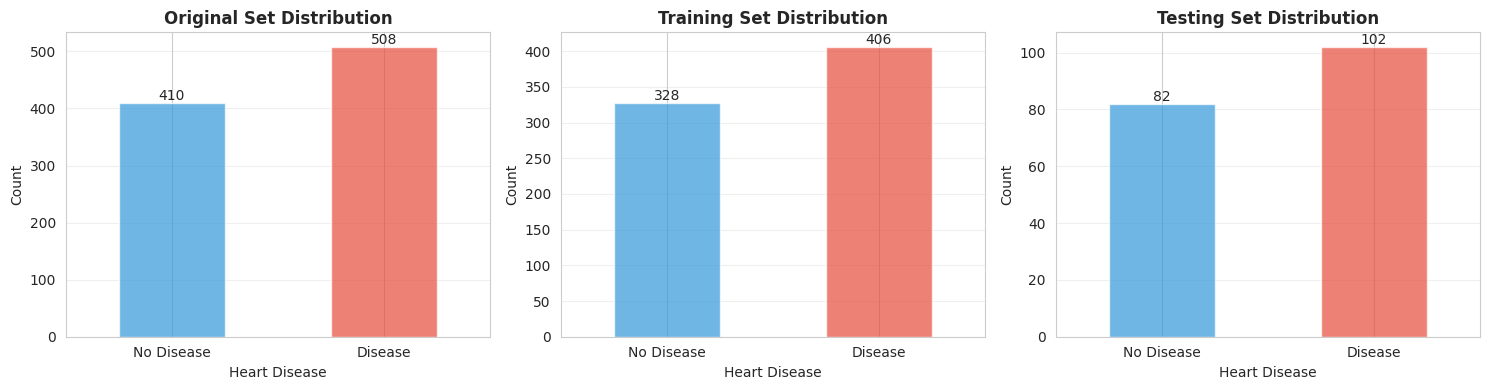


✓ Stratification successful – class balance maintained!


In [61]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [(y, "Original"), (y_train, "Training"), (y_test, "Testing")]

for ax, (data, title) in zip(axes, datasets):
    bars = data.value_counts().sort_index().plot(
        kind='bar',
        ax=ax,
        color=['#3498db', '#e74c3c'],
        alpha=0.7
    )

    ax.set_title(f"{title} Set Distribution", fontsize=12, fontweight='bold')
    ax.set_xlabel("Heart Disease", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_xticklabels(['No Disease', 'Disease'], rotation=0)
    ax.grid(True, alpha=0.3, axis='y')

    # Tambahkan label angka pada tiap bar
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

print("\n✓ Stratification successful – class balance maintained!")

## 2.6 FEATURE SCALING (STANDARDIZATION)


--- 2.6 Feature Scaling (Standardization) ---

✓ Features standardized successfully!
  Method: Z-score normalization (mean=0, std=1)
  Training set shape: (734, 21)
  Testing set shape: (184, 21)

📌 Standardization Verification (Training Set):
  Mean (should be ~0): -0.000000
  Std (should be ~1): 1.000682


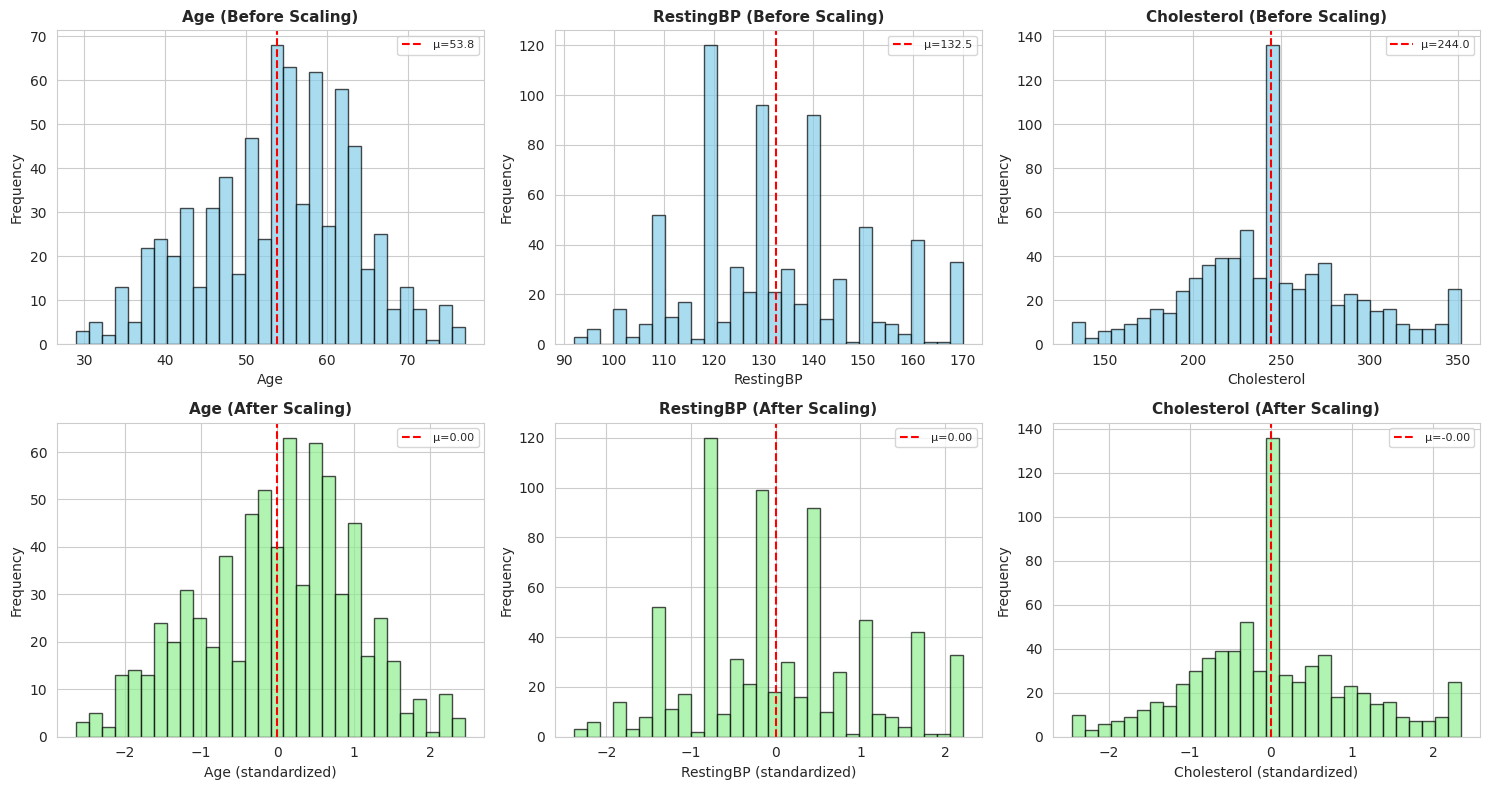


✓ Data preparation for classification completed!
  Ready for modeling with 21 features


In [ ]:
# Standardisasi fitur agar memiliki mean=0 dan std=1

print("\n--- 2.6 Feature Scaling (Standardization) ---")

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit pada training data dan transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame untuk kemudahan
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\n✓ Features standardized successfully!")
print(f"  Method: Z-score normalization (mean=0, std=1)")
print(f"  Training set shape: {X_train_scaled.shape}")
print(f"  Testing set shape: {X_test_scaled.shape}")

# Verifikasi standardisasi pada training set
print(f"\n📌 Standardization Verification (Training Set):")
print(f"  Mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"  Std (should be ~1): {X_train_scaled.std().mean():.6f}")

# Visualisasi: Before & After Scaling (contoh 3 fitur)
sample_features = ['Age', 'RestingBP', 'Cholesterol']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, feature in enumerate(sample_features):
    # Before scaling
    axes[0, idx].hist(X_train[feature], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, idx].set_title(f'{feature} (Before Scaling)', fontsize=11, fontweight='bold')
    axes[0, idx].set_xlabel(feature)
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].axvline(X_train[feature].mean(), color='red', linestyle='--',
                        label=f'μ={X_train[feature].mean():.1f}')
    axes[0, idx].legend(fontsize=8)

    # After scaling
    axes[1, idx].hist(X_train_scaled[feature], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[1, idx].set_title(f'{feature} (After Scaling)', fontsize=11, fontweight='bold')
    axes[1, idx].set_xlabel(f'{feature} (standardized)')
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].axvline(X_train_scaled[feature].mean(), color='red', linestyle='--',
                        label=f'μ={X_train_scaled[feature].mean():.2f}')
    axes[1, idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n✓ Data preparation for classification completed!")
print(f"  Ready for modeling with {X_train_scaled.shape[1]} features")

# 3. CLASSIFICATION MODELING

## 3.1 RANDOM FOREST CLASSIFIER

In [ ]:
# Training Random Forest dengan GridSearchCV untuk hyperparameter tuning

print("\n" + "="*80)
print("3. CLASSIFICATION MODELING")
print("="*80)

print("\n--- 3.1 Random Forest Classifier ---")

# Dictionary untuk menyimpan model
models = {}
results = {}

# Definisikan parameter grid untuk Random Forest
rf_params = {
    'n_estimators': [100, 200, 300, 500],           # Jumlah decision trees
    'max_depth': [None, 10, 20, 30],                # Kedalaman maksimum tree
    'min_samples_split': [2, 5, 10],                # Minimum sampel untuk split node
    'min_samples_leaf': [1, 2, 4],                  # Minimum sampel di leaf node
    'max_features': ['sqrt', 'log2'],               # Jumlah fitur untuk split
    'class_weight': [None, 'balanced']              # Bobot kelas untuk imbalance
}

print("\n📌 Hyperparameter Grid:")
for param, values in rf_params.items():
    print(f"  {param}: {values}")

print(f"\n📌 Total combinations to test: {np.prod([len(v) for v in rf_params.values()])}")
print("📌 Performing GridSearchCV with 5-Fold Cross-Validation...")
print("   (This may take several minutes...)")

# Inisialisasi Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV dengan 5-fold CV
rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=5,                    # 5-fold cross-validation
    scoring='f1',            # Optimisasi berdasarkan F1-score
    n_jobs=-1,               # Gunakan semua CPU cores
    verbose=1
)

# Training
rf_grid.fit(X_train_scaled, y_train)

# Simpan best model
models['Random Forest'] = rf_grid.best_estimator_

print(f"\n✓ Training completed!")
print(f"\n📌 Best Hyperparameters:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📌 Best Cross-Validation F1-Score: {rf_grid.best_score_:.4f}")

# Evaluasi pada training dan testing set
y_train_pred_rf = rf_grid.best_estimator_.predict(X_train_scaled)
y_test_pred_rf = rf_grid.best_estimator_.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred_rf)
test_acc = accuracy_score(y_test, y_test_pred_rf)

print(f"\n📌 Training Accuracy: {train_acc:.4f}")
print(f"📌 Testing Accuracy: {test_acc:.4f}")
print(f"📌 Overfitting Check: {abs(train_acc - test_acc):.4f} " +
      ("(Good)" if abs(train_acc - test_acc) < 0.05 else "(Check for overfitting)"))


3. CLASSIFICATION MODELING

--- 3.1 Random Forest Classifier ---

📌 Hyperparameter Grid:
  n_estimators: [100, 200, 300, 500]
  max_depth: [None, 10, 20, 30]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']
  class_weight: [None, 'balanced']

📌 Total combinations to test: 576
📌 Performing GridSearchCV with 5-Fold Cross-Validation...
   (This may take several minutes...)
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

✓ Training completed!

📌 Best Hyperparameters:
  class_weight: None
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 10
  n_estimators: 500

📌 Best Cross-Validation F1-Score: 0.8865

📌 Training Accuracy: 0.9469
📌 Testing Accuracy: 0.9076
📌 Overfitting Check: 0.0393 (Good)


## 3.2 SUPPORT VECTOR MACHINE (SVM)

In [ ]:
# Training SVM dengan GridSearchCV

print("\n--- 3.2 Support Vector Machine (SVM) ---")

# Parameter grid untuk SVM
svm_params = {
    'C': [0.1, 1, 10, 100],                   # Regularization parameter
    'kernel': ['rbf', 'linear'],              # Kernel function
    'gamma': ['scale', 'auto', 0.01, 0.1],    # Kernel coefficient
    'class_weight': [None, 'balanced']
}

print("\n📌 Hyperparameter Grid:")
for param, values in svm_params.items():
    print(f"  {param}: {values}")

print(f"\n📌 Total combinations to test: {np.prod([len(v) for v in svm_params.values()])}")
print("📌 Performing GridSearchCV with 5-Fold Cross-Validation...")

# Inisialisasi SVM
svm = SVC(random_state=42, probability=True)  # probability=True untuk predict_proba

# GridSearchCV
svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Training
svm_grid.fit(X_train_scaled, y_train)

# Simpan best model
models['SVM'] = svm_grid.best_estimator_

print(f"\n✓ Training completed!")
print(f"\n📌 Best Hyperparameters:")
for param, value in svm_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📌 Best Cross-Validation F1-Score: {svm_grid.best_score_:.4f}")


--- 3.2 Support Vector Machine (SVM) ---

📌 Hyperparameter Grid:
  C: [0.1, 1, 10, 100]
  kernel: ['rbf', 'linear']
  gamma: ['scale', 'auto', 0.01, 0.1]
  class_weight: [None, 'balanced']

📌 Total combinations to test: 64
📌 Performing GridSearchCV with 5-Fold Cross-Validation...
Fitting 5 folds for each of 64 candidates, totalling 320 fits

✓ Training completed!

📌 Best Hyperparameters:
  C: 10
  class_weight: None
  gamma: scale
  kernel: linear

📌 Best Cross-Validation F1-Score: 0.8876


## 3.3 K-NEAREST NEIGHBORS (KNN)

In [ ]:
# Training KNN dengan GridSearchCV

print("\n--- 3.3 K-Nearest Neighbors (KNN) ---")

# Parameter grid untuk KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],          # Jumlah tetangga
    'weights': ['uniform', 'distance'],        # Bobot tetangga
    'metric': ['euclidean', 'manhattan']       # Distance metric
}

print("\n📌 Hyperparameter Grid:")
for param, values in knn_params.items():
    print(f"  {param}: {values}")

print(f"\n📌 Total combinations to test: {np.prod([len(v) for v in knn_params.values()])}")
print("📌 Performing GridSearchCV with 5-Fold Cross-Validation...")

# Inisialisasi KNN
knn = KNeighborsClassifier()

# GridSearchCV
knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=knn_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Training
knn_grid.fit(X_train_scaled, y_train)

# Simpan best model
models['KNN'] = knn_grid.best_estimator_

print(f"\n✓ Training completed!")
print(f"\n📌 Best Hyperparameters:")
for param, value in knn_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📌 Best Cross-Validation F1-Score: {knn_grid.best_score_:.4f}")


--- 3.3 K-Nearest Neighbors (KNN) ---

📌 Hyperparameter Grid:
  n_neighbors: [3, 5, 7, 9, 11]
  weights: ['uniform', 'distance']
  metric: ['euclidean', 'manhattan']

📌 Total combinations to test: 20
📌 Performing GridSearchCV with 5-Fold Cross-Validation...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Training completed!

📌 Best Hyperparameters:
  metric: manhattan
  n_neighbors: 9
  weights: distance

📌 Best Cross-Validation F1-Score: 0.8619


## 3.4 LOGISTIC REGRESSION

In [ ]:
# Training Logistic Regression dengan GridSearchCV

print("\n--- 3.4 Logistic Regression ---")

# Parameter grid untuk Logistic Regression
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],             # Inverse regularization strength
    'penalty': ['l2'],                         # Regularization type
    'solver': ['lbfgs', 'saga'],              # Optimization algorithm
    'class_weight': [None, 'balanced']
}

print("\n📌 Hyperparameter Grid:")
for param, values in lr_params.items():
    print(f"  {param}: {values}")

print(f"\n📌 Total combinations to test: {np.prod([len(v) for v in lr_params.values()])}")
print("📌 Performing GridSearchCV with 5-Fold Cross-Validation...")

# Inisialisasi Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)

# GridSearchCV
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Training
lr_grid.fit(X_train_scaled, y_train)

# Simpan best model
models['Logistic Regression'] = lr_grid.best_estimator_

print(f"\n✓ Training completed!")
print(f"\n📌 Best Hyperparameters:")
for param, value in lr_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n📌 Best Cross-Validation F1-Score: {lr_grid.best_score_:.4f}")


--- 3.4 Logistic Regression ---

📌 Hyperparameter Grid:
  C: [0.01, 0.1, 1, 10, 100]
  penalty: ['l2']
  solver: ['lbfgs', 'saga']
  class_weight: [None, 'balanced']

📌 Total combinations to test: 20
📌 Performing GridSearchCV with 5-Fold Cross-Validation...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Training completed!

📌 Best Hyperparameters:
  C: 1
  class_weight: None
  penalty: l2
  solver: lbfgs

📌 Best Cross-Validation F1-Score: 0.8720


In [ ]:
print("\n" + "="*80)
print("✓ ALL CLASSIFICATION MODELS TRAINED SUCCESSFULLY!")
print("="*80)


✓ ALL CLASSIFICATION MODELS TRAINED SUCCESSFULLY!


## 3.5 MODEL EVALUATION

In [ ]:
# Evaluasi performa semua model pada testing set

print("\n--- 3.5 Model Evaluation on Test Set ---")

print("\n" + "="*80)
print("EVALUATING ALL MODELS")
print("="*80)

# Evaluasi setiap model
for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"📊 {name}")
    print('='*80)

    # Prediksi
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Hitung metrik
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    # Simpan hasil
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    # Tampilkan metrik
    print(f"\n📌 Performance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    print(f"  AUC-ROC:   {auc_roc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n📌 Confusion Matrix:")
    print(f"                Predicted")
    print(f"                No    Yes")
    print(f"  Actual No   {tn:4d}  {fp:4d}")
    print(f"         Yes  {fn:4d}  {tp:4d}")

    # Tambahan: Sensitivity & Specificity
    sensitivity = recall  # Same as recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"\n📌 Additional Metrics:")
    print(f"  Sensitivity (TPR): {sensitivity:.4f}")
    print(f"  Specificity (TNR): {specificity:.4f}")
    print(f"  False Positive Rate: {fp/(fp+tn):.4f}")
    print(f"  False Negative Rate: {fn/(fn+tp):.4f}")

print("\n" + "="*80)
print("✓ MODEL EVALUATION COMPLETED!")
print("="*80)


--- 3.5 Model Evaluation on Test Set ---

EVALUATING ALL MODELS

📊 Random Forest

📌 Performance Metrics:
  Accuracy:  0.9076 (90.76%)
  Precision: 0.9208 (92.08%)
  Recall:    0.9118 (91.18%)
  F1-Score:  0.9163 (91.63%)
  AUC-ROC:   0.9481

📌 Confusion Matrix:
                Predicted
                No    Yes
  Actual No     74     8
         Yes     9    93

📌 Additional Metrics:
  Sensitivity (TPR): 0.9118
  Specificity (TNR): 0.9024
  False Positive Rate: 0.0976
  False Negative Rate: 0.0882

📊 SVM

📌 Performance Metrics:
  Accuracy:  0.8859 (88.59%)
  Precision: 0.9091 (90.91%)
  Recall:    0.8824 (88.24%)
  F1-Score:  0.8955 (89.55%)
  AUC-ROC:   0.9250

📌 Confusion Matrix:
                Predicted
                No    Yes
  Actual No     73     9
         Yes    12    90

📌 Additional Metrics:
  Sensitivity (TPR): 0.8824
  Specificity (TNR): 0.8902
  False Positive Rate: 0.1098
  False Negative Rate: 0.1176

📊 KNN

📌 Performance Metrics:
  Accuracy:  0.8804 (88.04%)
  Preci

## 3.6 MODEL COMPARISON

In [ ]:
# Membandingkan performa semua model

print("\n--- 3.6 Model Comparison ---")

# Buat DataFrame untuk perbandingan
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.drop(['y_pred', 'y_pred_proba'], axis=1)

print("\n📊 Model Comparison Summary:")
print("="*80)
display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

# Identifikasi best model berdasarkan F1-Score
best_model_name = comparison_df['F1-Score'].idxmax()
best_model = models[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"="*80)
print(f"  F1-Score:  {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"  Accuracy:  {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"  Precision: {comparison_df.loc[best_model_name, 'Precision']:.4f}")
print(f"  Recall:    {comparison_df.loc[best_model_name, 'Recall']:.4f}")
print(f"  AUC-ROC:   {comparison_df.loc[best_model_name, 'AUC-ROC']:.4f}")

# Cek pencapaian business objectives
print(f"\n📌 Business Objectives Achievement:")
print("-" * 80)

objectives = {
    'Accuracy': (0.85, '≥'),
    'Precision': (0.80, '≥'),
    'Recall': (0.85, '≥'),
    'F1-Score': (0.82, '≥'),
    'AUC-ROC': (0.85, '>')
}

all_passed = True
for metric, (threshold, operator) in objectives.items():
    value = comparison_df.loc[best_model_name, metric]

    if operator == '≥':
        passed = value >= threshold
    else:  # '>'
        passed = value > threshold

    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {metric:12s}: {value:.4f} {operator} {threshold:.2f}  [{status}]")

    if not passed:
        all_passed = False

if all_passed:
    print(f"\n🎉 ALL BUSINESS OBJECTIVES MET!")
else:
    print(f"\n⚠️  Some objectives not met - consider model improvement")


--- 3.6 Model Comparison ---

📊 Model Comparison Summary:


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest,0.907609,0.920792,0.911765,0.916256,0.948111
SVM,0.885870,0.909091,0.882353,0.895522,0.925036
KNN,0.880435,0.877358,0.911765,0.894231,0.941655
Logistic Regression,0.891304,0.901961,0.901961,0.901961,0.930057



🏆 BEST MODEL: Random Forest
  F1-Score:  0.9163
  Accuracy:  0.9076
  Precision: 0.9208
  Recall:    0.9118
  AUC-ROC:   0.9481

📌 Business Objectives Achievement:
--------------------------------------------------------------------------------
  Accuracy    : 0.9076 ≥ 0.85  [✓ PASS]
  Precision   : 0.9208 ≥ 0.80  [✓ PASS]
  Recall      : 0.9118 ≥ 0.85  [✓ PASS]
  F1-Score    : 0.9163 ≥ 0.82  [✓ PASS]
  AUC-ROC     : 0.9481 > 0.85  [✓ PASS]

🎉 ALL BUSINESS OBJECTIVES MET!


## 3.7 VISUALISASI PERBANDINGAN MODEL


--- 3.7 Model Comparison Visualizations ---


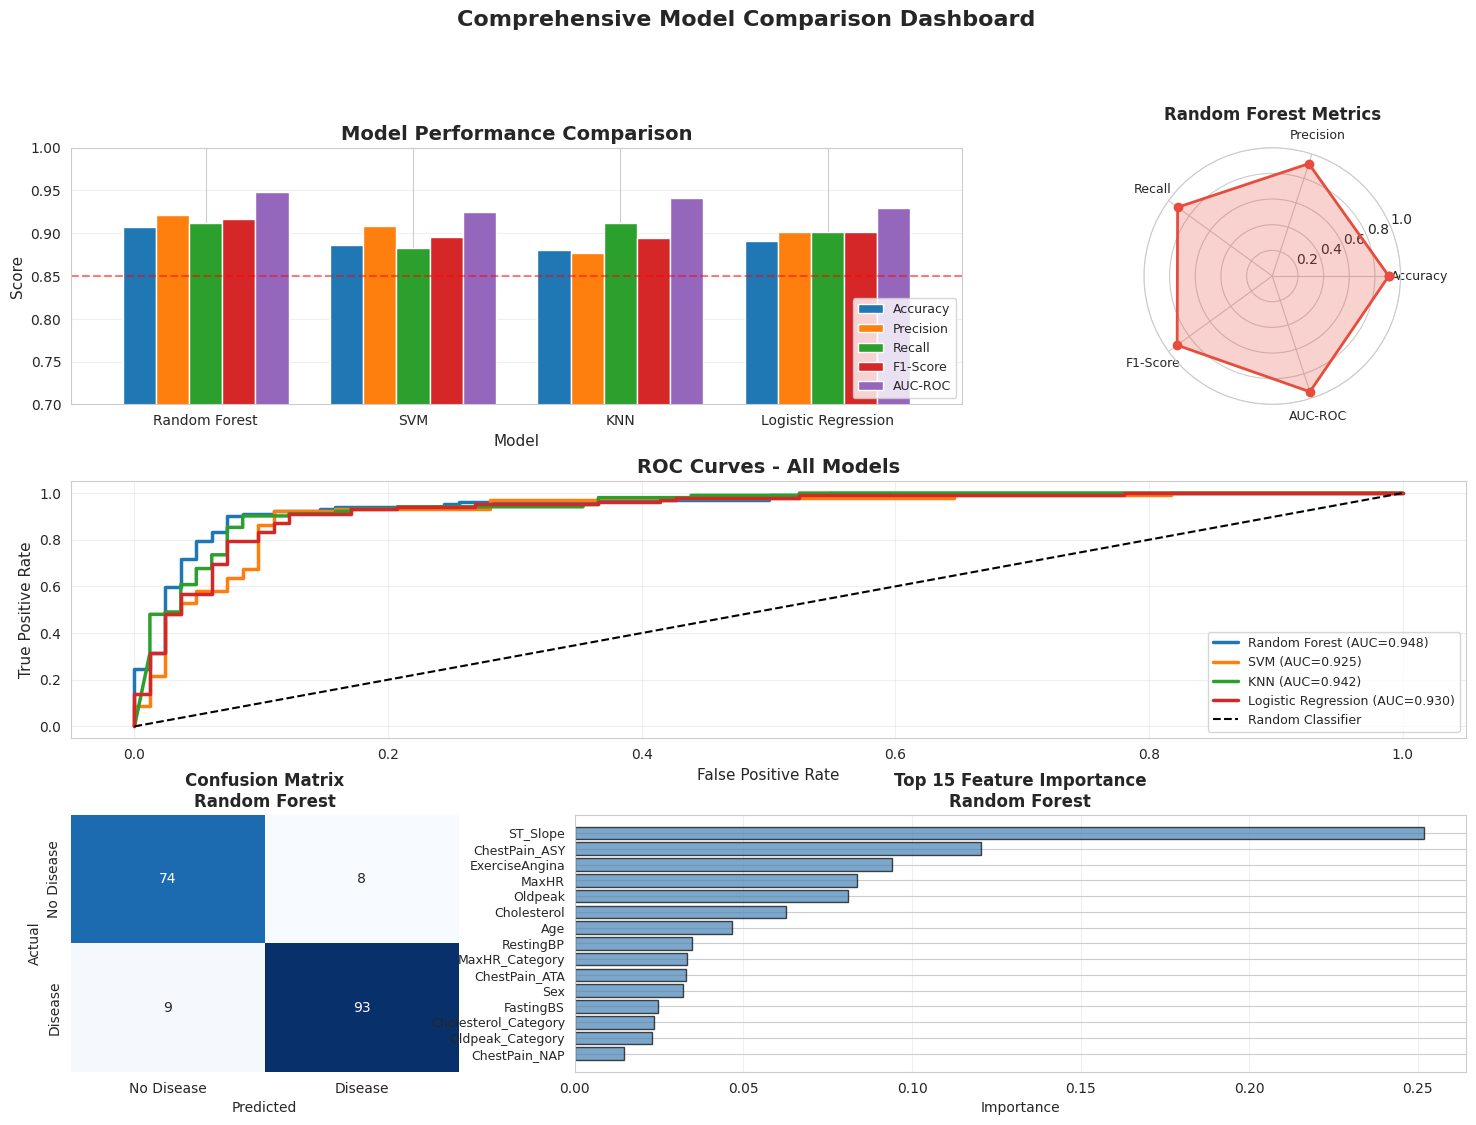


✓ Visualizations completed!


In [ ]:
# Visualisasi performa model secara komprehensif

print("\n--- 3.7 Model Comparison Visualizations ---")

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Bar Plot: Metrics Comparison
ax1 = fig.add_subplot(gs[0, :2])
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].plot(
    kind='bar', ax=ax1, width=0.8, rot=0)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11)
ax1.set_xlabel('Model', fontsize=11)
ax1.legend(loc='lower right', fontsize=9)
ax1.set_ylim([0.7, 1.0])
ax1.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target (0.85)')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Radar Chart: Best Model Performance
ax2 = fig.add_subplot(gs[0, 2], projection='polar')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = comparison_df.loc[best_model_name, metrics].values
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))  # Close the plot
angles += angles[:1]

ax2.plot(angles, values, 'o-', linewidth=2, label=best_model_name, color='#e74c3c')
ax2.fill(angles, values, alpha=0.25, color='#e74c3c')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics, fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_title(f'{best_model_name} Metrics', fontsize=12, fontweight='bold', pad=20)
ax2.grid(True)

# 3. ROC Curves
ax3 = fig.add_subplot(gs[1, :])
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    auc = result['AUC-ROC']
    ax3.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2.5)

ax3.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
ax3.set_xlabel('False Positive Rate', fontsize=11)
ax3.set_ylabel('True Positive Rate', fontsize=11)
ax3.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Confusion Matrix: Best Model
ax4 = fig.add_subplot(gs[2, 0])
y_pred_best = results[best_model_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
ax4.set_title(f'Confusion Matrix\n{best_model_name}', fontsize=12, fontweight='bold')
ax4.set_ylabel('Actual', fontsize=10)
ax4.set_xlabel('Predicted', fontsize=10)

# 5. Feature Importance (Random Forest)
ax5 = fig.add_subplot(gs[2, 1:])
if best_model_name == 'Random Forest':
    rf_model = models['Random Forest']
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    ax5.barh(range(len(feature_importance)), feature_importance['Importance'],
             color='steelblue', alpha=0.7, edgecolor='black')
    ax5.set_yticks(range(len(feature_importance)))
    ax5.set_yticklabels(feature_importance['Feature'], fontsize=9)
    ax5.set_xlabel('Importance', fontsize=10)
    ax5.set_title(f'Top 15 Feature Importance\n{best_model_name}', fontsize=12, fontweight='bold')
    ax5.invert_yaxis()
    ax5.grid(True, alpha=0.3, axis='x')
else:
    ax5.text(0.5, 0.5, 'Feature importance only available\nfor Random Forest',
             ha='center', va='center', fontsize=12)
    ax5.axis('off')

plt.suptitle('Comprehensive Model Comparison Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n✓ Visualizations completed!")

## 3.8 SAVE MODELS & RESULTS

In [ ]:
# Menyimpan model terbaik dan hasil evaluasi

print("\n--- 3.8 Saving Models & Results ---")

import pickle

# Save best model
with open('best_classification_model.pkl', 'wb') as f:
    pickle.dump(models[best_model_name], f)
print(f"✓ Best model saved: best_classification_model.pkl ({best_model_name})")

# Save scaler (penting untuk preprocessing data baru)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler saved: scaler.pkl")

# Save all models
with open('all_classification_models.pkl', 'wb') as f:
    pickle.dump(models, f)
print("✓ All models saved: all_classification_models.pkl")

# Save comparison results
comparison_df.to_csv('model_comparison.csv')
print("✓ Comparison results saved: model_comparison.csv")

# Save feature importance (if Random Forest)
if best_model_name == 'Random Forest':
    rf_model = models['Random Forest']
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    feature_importance.to_csv('feature_importance.csv', index=False)
    print("✓ Feature importance saved: feature_importance.csv")

print("\n" + "="*80)
print("✓ CLASSIFICATION PHASE COMPLETED SUCCESSFULLY!")
print("="*80)


--- 3.8 Saving Models & Results ---
✓ Best model saved: best_classification_model.pkl (Random Forest)
✓ Scaler saved: scaler.pkl
✓ All models saved: all_classification_models.pkl
✓ Comparison results saved: model_comparison.csv
✓ Feature importance saved: feature_importance.csv

✓ CLASSIFICATION PHASE COMPLETED SUCCESSFULLY!


# 4. DATA PREPARATION & ASSOCIATION RULE MINING

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## 4.1 IDENTIFIKASI PASIEN BERISIKO TINGGI


4. DATA PREPARATION & ASSOCIATION RULE MINING

--- 4.1 Identifying High-Risk Patients ---

📌 Using Random Forest for risk prediction...

📊 Risk Classification Summary:
  Total patients: 918
  Predicted as disease (1): 522 (56.9%)
  High confidence (≥70%): 423 (46.1%)

✓ High-risk patients for ARM: 423


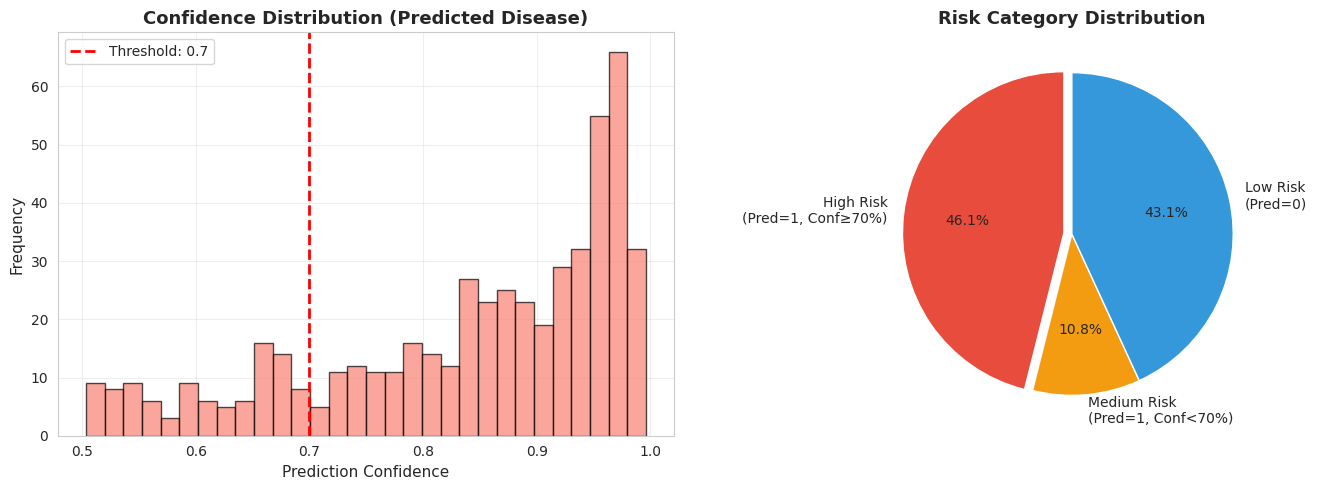

In [ ]:
# Menggunakan model terbaik untuk mengidentifikasi pasien high-risk

print("\n" + "="*80)
print("4. DATA PREPARATION & ASSOCIATION RULE MINING")
print("="*80)

print("\n--- 4.1 Identifying High-Risk Patients ---")

# Gunakan model terbaik untuk prediksi pada seluruh dataset
print(f"\n📌 Using {best_model_name} for risk prediction...")

# Standardize seluruh dataset
X_all_scaled = scaler.transform(X)

# Prediksi dan probabilitas
y_pred_all = best_model.predict(X_all_scaled)
y_pred_proba_all = best_model.predict_proba(X_all_scaled)[:, 1]

# Filter high-risk patients (predicted=1 dengan confidence ≥70%)
confidence_threshold = 0.7
high_risk_mask = (y_pred_all == 1) & (y_pred_proba_all >= confidence_threshold)

print(f"\n📊 Risk Classification Summary:")
print(f"  Total patients: {len(df)}")
print(f"  Predicted as disease (1): {(y_pred_all == 1).sum()} ({(y_pred_all == 1).sum()/len(df)*100:.1f}%)")
print(f"  High confidence (≥{confidence_threshold*100:.0f}%): {high_risk_mask.sum()} ({high_risk_mask.sum()/len(df)*100:.1f}%)")
print(f"\n✓ High-risk patients for ARM: {high_risk_mask.sum()}")

# Visualisasi distribusi confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram confidence
axes[0].hist(y_pred_proba_all[y_pred_all == 1], bins=30, edgecolor='black',
             alpha=0.7, color='salmon')
axes[0].axvline(confidence_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Threshold: {confidence_threshold}')
axes[0].set_xlabel('Prediction Confidence', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Confidence Distribution (Predicted Disease)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pie chart risk categories
risk_categories = pd.Series({
    'High Risk\n(Pred=1, Conf≥70%)': high_risk_mask.sum(),
    'Medium Risk\n(Pred=1, Conf<70%)': ((y_pred_all == 1) & (y_pred_proba_all < confidence_threshold)).sum(),
    'Low Risk\n(Pred=0)': (y_pred_all == 0).sum()
})

axes[1].pie(risk_categories, labels=risk_categories.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#f39c12', '#3498db'], startangle=90, explode=(0.05, 0, 0))
axes[1].set_title('Risk Category Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 4.2 PERSIAPAN DATA UNTUK ARM


--- 4.2 Preparing Categorical Dataset for ARM ---

📌 Creating categorical features for ARM...
  Dataset size: 423 high-risk patients
  ✓ Age_Cat: Young (<40), Middle (40-60), Senior (>60)
  ✓ BP_Cat: Normal, Prehypertension, Stage1, Stage2
  ✓ Chol_Cat: Desirable (<200), Borderline (200-240), High (>240)
  ✓ MaxHR_Cat: Low, Medium, High
  ✓ Oldpeak_Cat: No, Mild, Moderate, Severe
  ✓ All categorical features created

📊 ARM Dataset Summary:
  Features: 11
  Rows (after dropping NaN): 282
  Dropped rows: 141

📌 Visualizing categorical features distribution...


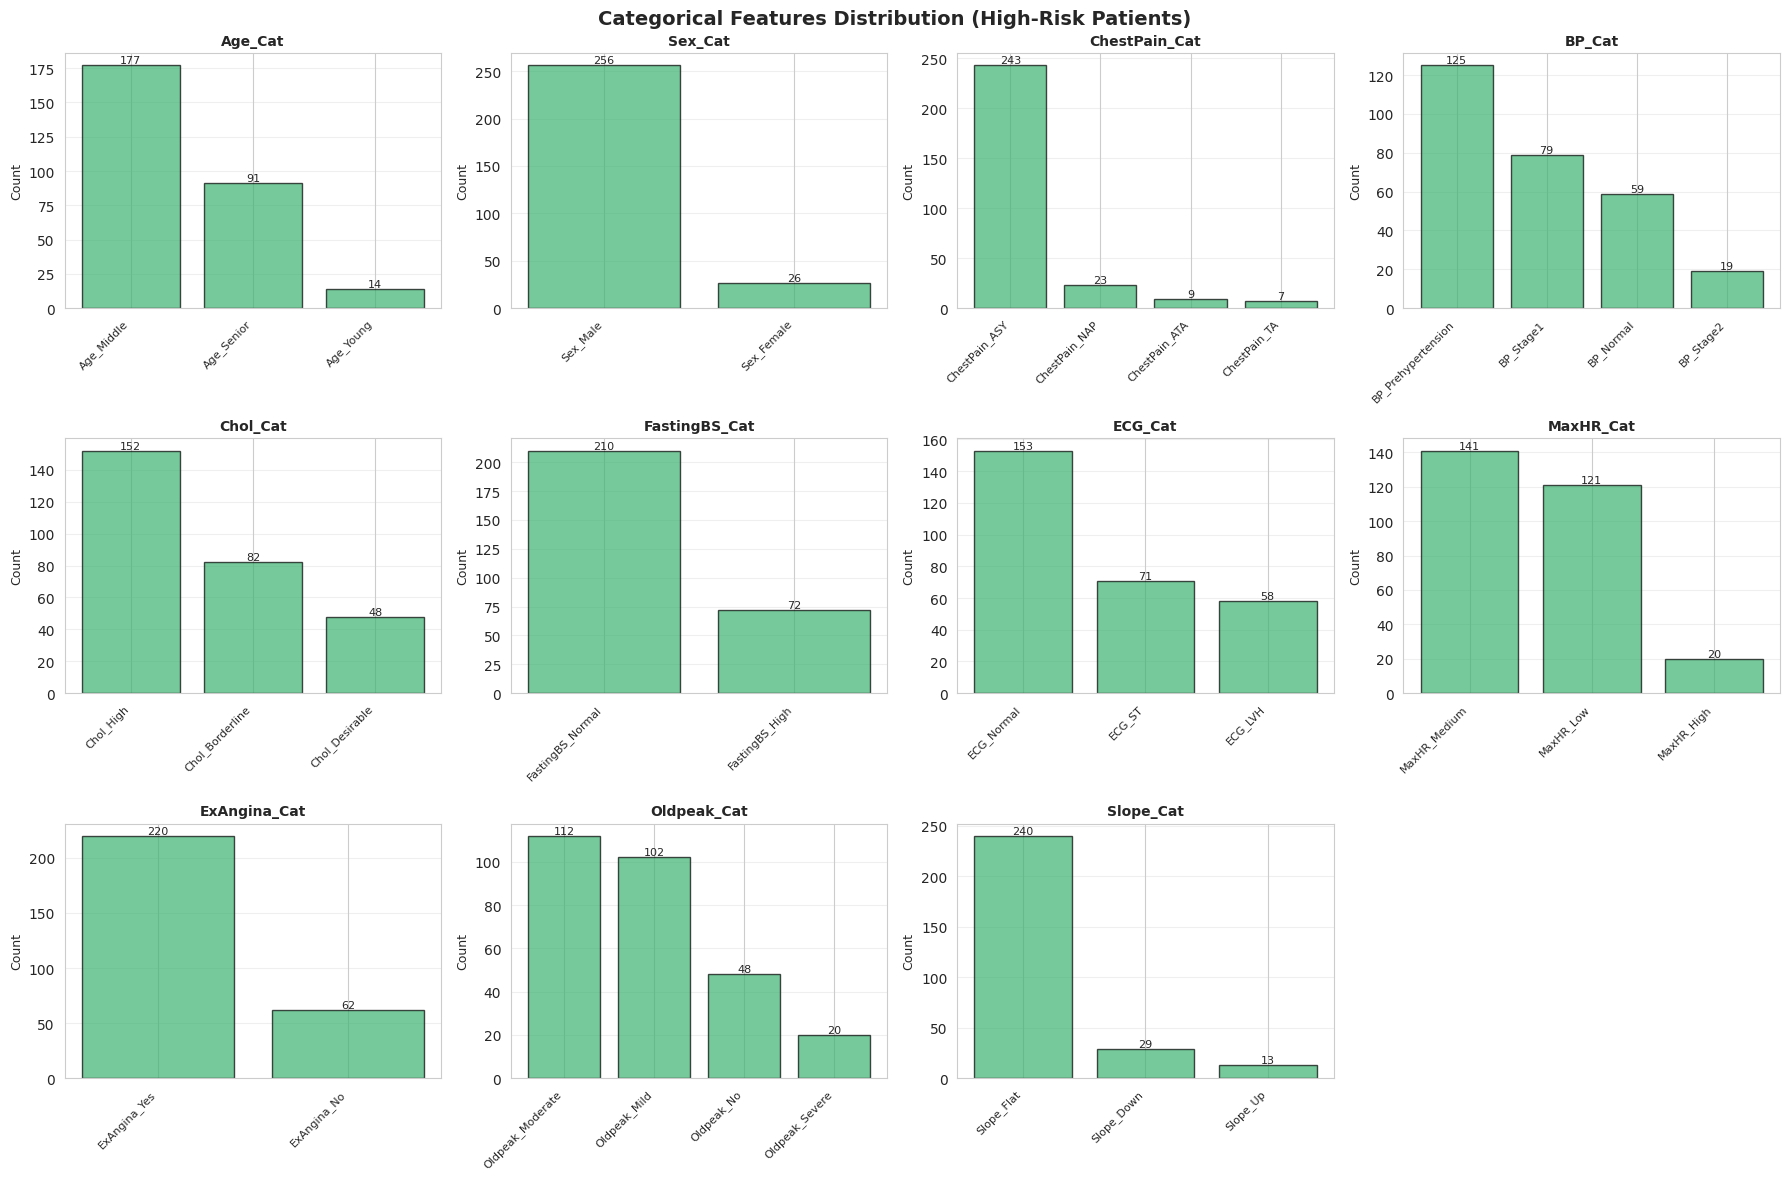


✓ Data preparation for ARM completed!


In [ ]:
# Membuat dataset kategorikal untuk Association Rule Mining

print("\n--- 4.2 Preparing Categorical Dataset for ARM ---")

# Ambil data asli untuk high-risk patients
arm_data = df[high_risk_mask].copy()

print(f"\n📌 Creating categorical features for ARM...")
print(f"  Dataset size: {len(arm_data)} high-risk patients")

# 1. Kategorisasi Age
arm_data['Age_Cat'] = pd.cut(arm_data['Age'],
                              bins=[0, 40, 60, 100],
                              labels=['Age_Young', 'Age_Middle', 'Age_Senior'])
print("  ✓ Age_Cat: Young (<40), Middle (40-60), Senior (>60)")

# 2. Kategorisasi Blood Pressure (AHA guidelines)
arm_data['BP_Cat'] = pd.cut(arm_data['RestingBP'],
                             bins=[0, 120, 140, 160, 200],
                             labels=['BP_Normal', 'BP_Prehypertension',
                                     'BP_Stage1', 'BP_Stage2'])
print("  ✓ BP_Cat: Normal, Prehypertension, Stage1, Stage2")

# 3. Kategorisasi Cholesterol (NCEP guidelines)
arm_data['Chol_Cat'] = pd.cut(arm_data['Cholesterol'],
                               bins=[0, 200, 240, 400],
                               labels=['Chol_Desirable', 'Chol_Borderline', 'Chol_High'])
print("  ✓ Chol_Cat: Desirable (<200), Borderline (200-240), High (>240)")

# 4. Kategorisasi MaxHR
arm_data['MaxHR_Cat'] = pd.cut(arm_data['MaxHR'],
                                bins=[0, 120, 150, 250],
                                labels=['MaxHR_Low', 'MaxHR_Medium', 'MaxHR_High'])
print("  ✓ MaxHR_Cat: Low, Medium, High")

# 5. Kategorisasi Oldpeak (ST depression)
arm_data['Oldpeak_Cat'] = pd.cut(arm_data['Oldpeak'],
                                  bins=[-1, 0, 1.5, 3.0, 10],
                                  labels=['Oldpeak_No', 'Oldpeak_Mild',
                                          'Oldpeak_Moderate', 'Oldpeak_Severe'])
print("  ✓ Oldpeak_Cat: No, Mild, Moderate, Severe")

# 6. Map categorical variables dengan label deskriptif
arm_data['Sex_Cat'] = arm_data['Sex'].map({'M': 'Sex_Male', 'F': 'Sex_Female'})
arm_data['ChestPain_Cat'] = arm_data['ChestPainType'].apply(lambda x: f'ChestPain_{x}')
arm_data['ECG_Cat'] = arm_data['RestingECG'].apply(lambda x: f'ECG_{x}')
arm_data['ExAngina_Cat'] = arm_data['ExerciseAngina'].map({'Y': 'ExAngina_Yes', 'N': 'ExAngina_No'})
arm_data['Slope_Cat'] = arm_data['ST_Slope'].apply(lambda x: f'Slope_{x}')
arm_data['FastingBS_Cat'] = arm_data['FastingBS'].map({1: 'FastingBS_High', 0: 'FastingBS_Normal'})

print("  ✓ All categorical features created")

# Pilih kolom untuk ARM
arm_columns = ['Age_Cat', 'Sex_Cat', 'ChestPain_Cat', 'BP_Cat', 'Chol_Cat',
               'FastingBS_Cat', 'ECG_Cat', 'MaxHR_Cat', 'ExAngina_Cat',
               'Oldpeak_Cat', 'Slope_Cat']

arm_dataset = arm_data[arm_columns].copy()

# Convert to string dan handle NaN
for col in arm_columns:
    arm_dataset[col] = arm_dataset[col].astype(str)
    arm_dataset[col] = arm_dataset[col].replace('nan', np.nan)

# Drop rows dengan NaN
initial_rows = len(arm_dataset)
arm_dataset = arm_dataset.dropna()
dropped_rows = initial_rows - len(arm_dataset)

print(f"\n📊 ARM Dataset Summary:")
print(f"  Features: {len(arm_columns)}")
print(f"  Rows (after dropping NaN): {len(arm_dataset)}")
print(f"  Dropped rows: {dropped_rows}")

# Visualisasi distribusi fitur kategorikal
print("\n📌 Visualizing categorical features distribution...")

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(arm_columns):
    value_counts = arm_dataset[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values,
                  color='mediumseagreen', alpha=0.7, edgecolor='black')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Value labels
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v, str(v), ha='center', va='bottom', fontsize=8)

# Hapus subplot kosong
for idx in range(len(arm_columns), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Categorical Features Distribution (High-Risk Patients)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Data preparation for ARM completed!")

## 4.3 TRANSFORMASI KE FORMAT TRANSAKSI


--- 4.3 Transforming to Transaction Format ---

📊 Transaction Data:
  Number of transactions: 282
  Items per transaction: 11

📌 Sample Transactions:
  Transaction 1: ['Age_Middle', 'Sex_Female', 'ChestPain_ASY', 'BP_Prehypertension', 'Chol_Borderline', 'FastingBS_Normal', 'ECG_Normal', 'MaxHR_Low', 'ExAngina_Yes', 'Oldpeak_Mild', 'Slope_Flat']
  Transaction 2: ['Age_Young', 'Sex_Male', 'ChestPain_ASY', 'BP_Prehypertension', 'Chol_Borderline', 'FastingBS_Normal', 'ECG_Normal', 'MaxHR_Medium', 'ExAngina_Yes', 'Oldpeak_Mild', 'Slope_Flat']
  Transaction 3: ['Age_Middle', 'Sex_Male', 'ChestPain_ATA', 'BP_Prehypertension', 'Chol_Desirable', 'FastingBS_Normal', 'ECG_ST', 'MaxHR_Low', 'ExAngina_Yes', 'Oldpeak_Moderate', 'Slope_Flat']

📌 One-hot encoding transactions...

✓ Encoding completed:
  Encoded dataset shape: (282, 33)
  Number of unique items: 33

📌 Sample Encoded Data (first 5 rows, first 10 columns):


,Age_Middle,Age_Senior,Age_Young,BP_Normal,BP_Prehypertension,BP_Stage1,BP_Stage2,ChestPain_ASY,ChestPain_ATA,ChestPain_NAP
0,True,False,False,False,True,False,False,True,False,False
1,False,False,True,False,True,False,False,True,False,False
2,True,False,False,False,True,False,False,False,True,False
3,True,False,False,False,True,False,False,True,False,False
4,False,False,True,True,False,False,False,True,False,False



📌 Item Frequency Statistics:
  Top 10 most frequent items:
    Sex_Male: 256 (90.78%)
    ChestPain_ASY: 243 (86.17%)
    Slope_Flat: 240 (85.11%)
    ExAngina_Yes: 220 (78.01%)
    FastingBS_Normal: 210 (74.47%)
    Age_Middle: 177 (62.77%)
    ECG_Normal: 153 (54.26%)
    Chol_High: 152 (53.90%)
    MaxHR_Medium: 141 (50.00%)
    BP_Prehypertension: 125 (44.33%)


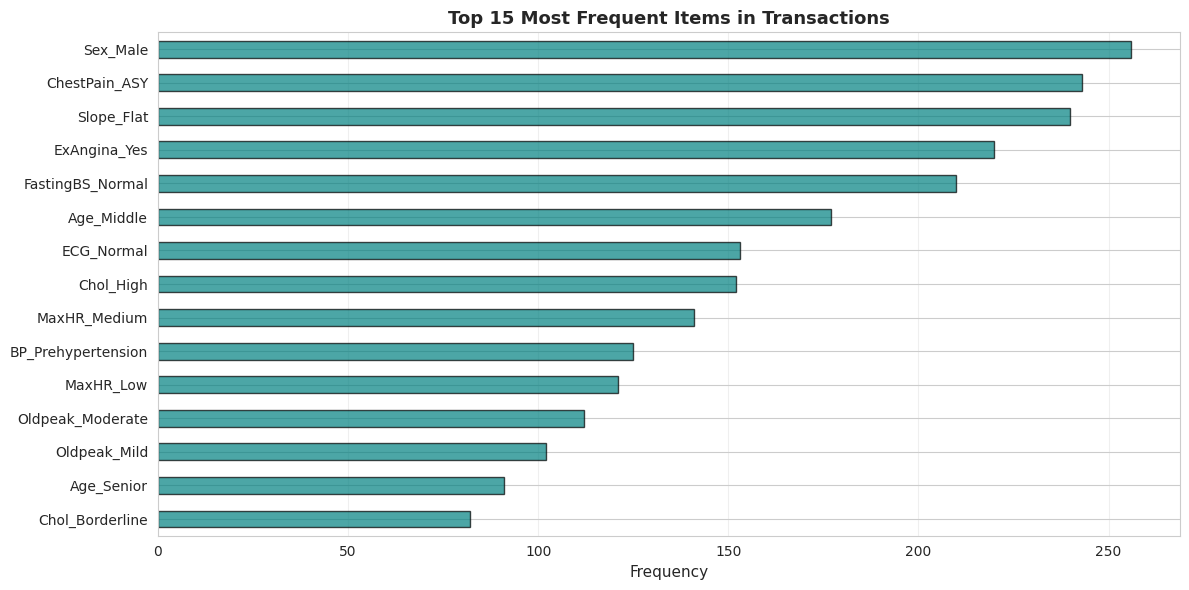


✓ Transaction format ready for Apriori algorithm!


In [ ]:
# Mengubah data ke format transaksi untuk Apriori algorithm

print("\n--- 4.3 Transforming to Transaction Format ---")

# Install mlxtend jika belum ada
!pip install -q mlxtend

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Buat list of transactions
# Setiap row = satu transaksi (list of items)
transactions = []
for idx, row in arm_dataset.iterrows():
    transaction = list(row.values)
    transactions.append(transaction)

print(f"\n📊 Transaction Data:")
print(f"  Number of transactions: {len(transactions)}")
print(f"  Items per transaction: {len(transactions[0])}")

# Tampilkan contoh transaksi
print(f"\n📌 Sample Transactions:")
for i in range(min(3, len(transactions))):
    print(f"  Transaction {i+1}: {transactions[i]}")

# One-hot encoding menggunakan TransactionEncoder
print(f"\n📌 One-hot encoding transactions...")
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\n✓ Encoding completed:")
print(f"  Encoded dataset shape: {df_encoded.shape}")
print(f"  Number of unique items: {len(te.columns_)}")

# Tampilkan sample encoded data
print(f"\n📌 Sample Encoded Data (first 5 rows, first 10 columns):")
display(df_encoded.iloc[:5, :10])

# Statistik item frequency
print(f"\n📌 Item Frequency Statistics:")
item_freq = df_encoded.sum().sort_values(ascending=False)
print(f"  Top 10 most frequent items:")
for item, freq in item_freq.head(10).items():
    support = freq / len(df_encoded)
    print(f"    {item}: {freq} ({support:.2%})")

# Visualisasi top items
plt.figure(figsize=(12, 6))
item_freq.head(15).plot(kind='barh', color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Frequency', fontsize=11)
plt.title('Top 15 Most Frequent Items in Transactions', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n✓ Transaction format ready for Apriori algorithm!")

## 4.4 APRIORI ALGORITHM


--- 4.4 Applying Apriori Algorithm ---

📌 Apriori Parameters:
  Minimum Support: 0.1 (10%)
  This means itemsets must appear in at least 28 transactions

📌 Finding frequent itemsets...
   (This may take a moment...)
Processing 16 combinations | Sampling itemset size 8

✓ Apriori completed!
  Frequent itemsets found: 1960

📊 Frequent Itemsets by Length:
  1-itemsets: 24
  2-itemsets: 170
  3-itemsets: 462
  4-itemsets: 626
  5-itemsets: 463
  6-itemsets: 189
  7-itemsets: 26

📌 Top 20 Frequent Itemsets:
----------------------------------------------------------------------------------------------------


,itemset_str,length,support
21,Sex_Male,1,0.9078
5,ChestPain_ASY,1,0.8617
23,Slope_Flat,1,0.8511
13,ExAngina_Yes,1,0.7801
105,"Sex_Male, ChestPain_ASY",2,0.7766
193,"Slope_Flat, Sex_Male",2,0.7660
15,FastingBS_Normal,1,0.7447
106,"Slope_Flat, ChestPain_ASY",2,0.7199
165,"Sex_Male, ExAngina_Yes",2,0.7057
97,"ChestPain_ASY, ExAngina_Yes",2,0.6844


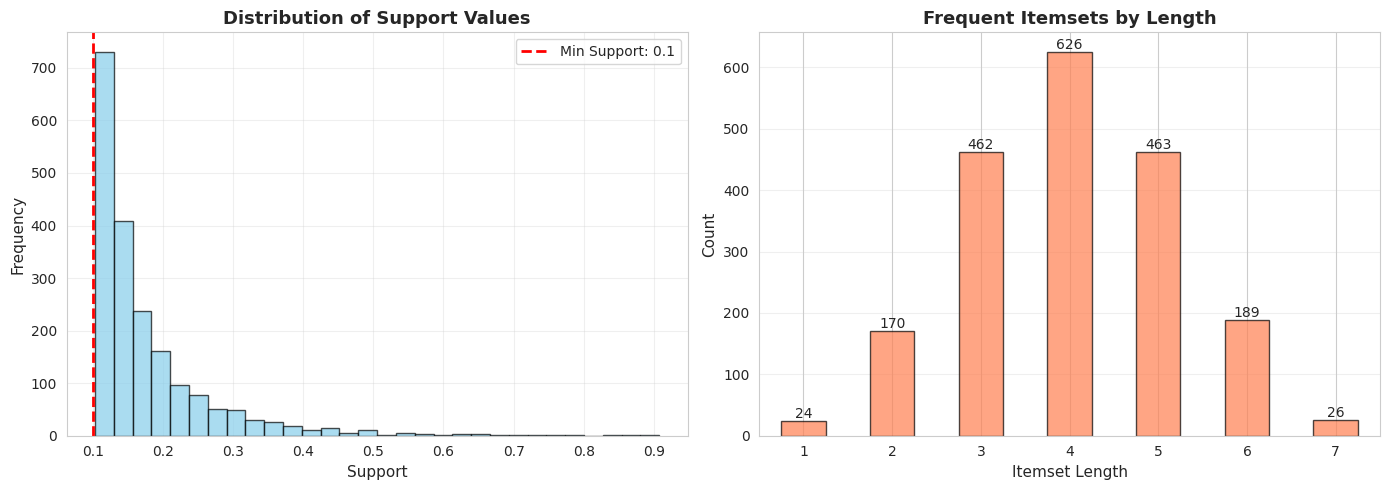


✓ Frequent itemsets analysis completed!


In [ ]:
# Mencari frequent itemsets menggunakan Apriori

print("\n--- 4.4 Applying Apriori Algorithm ---")

# Set parameter minimum support (sesuai paper: 10%)
min_support = 0.1

print(f"\n📌 Apriori Parameters:")
print(f"  Minimum Support: {min_support} ({min_support*100:.0f}%)")
print(f"  This means itemsets must appear in at least {int(min_support * len(df_encoded))} transactions")

print(f"\n📌 Finding frequent itemsets...")
print("   (This may take a moment...)")

# Apply Apriori algorithm
frequent_itemsets = apriori(df_encoded,
                            min_support=min_support,
                            use_colnames=True,
                            verbose=1)

print(f"\n✓ Apriori completed!")
print(f"  Frequent itemsets found: {len(frequent_itemsets)}")

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

# Analisis berdasarkan itemset length
print(f"\n📊 Frequent Itemsets by Length:")
itemset_lengths = frequent_itemsets['itemsets'].apply(lambda x: len(x))
length_counts = itemset_lengths.value_counts().sort_index()
for length, count in length_counts.items():
    print(f"  {length}-itemsets: {count}")

# Tampilkan top frequent itemsets
print(f"\n📌 Top 20 Frequent Itemsets:")
print("-" * 100)
top_itemsets = frequent_itemsets.head(20).copy()
top_itemsets['itemset_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
top_itemsets['length'] = top_itemsets['itemsets'].apply(lambda x: len(x))

display(top_itemsets[['itemset_str', 'length', 'support']].style.format({'support': '{:.4f}'}))

# Visualisasi distribusi support
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram support
axes[0].hist(frequent_itemsets['support'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(min_support, color='red', linestyle='--', linewidth=2, label=f'Min Support: {min_support}')
axes[0].set_xlabel('Support', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Support Values', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar plot itemset lengths
length_counts.plot(kind='bar', ax=axes[1], color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Itemset Length', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Frequent Itemsets by Length', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

# Value labels
for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

print("\n✓ Frequent itemsets analysis completed!")

## 4.5 GENERATE ASSOCIATION RULES

In [ ]:
# Membuat association rules dari frequent itemsets

print("\n--- 4.5 Generating Association Rules ---")

# Set thresholds (sesuai paper)
min_confidence = 0.6  # 60%
min_lift = 1.2

print(f"\n📌 Association Rule Parameters:")
print(f"  Minimum Confidence: {min_confidence} ({min_confidence*100:.0f}%)")
print(f"  Minimum Lift: {min_lift}")

print(f"\n📌 Generating rules...")

# Generate association rules
rules = association_rules(frequent_itemsets,
                         metric="confidence",
                         min_threshold=min_confidence,
                         num_itemsets=len(frequent_itemsets))

# Filter by lift
rules = rules[rules['lift'] >= min_lift]

print(f"\n✓ Rules generated!")
print(f"  Total rules (confidence ≥{min_confidence}): {len(association_rules(frequent_itemsets, metric='confidence', min_threshold=min_confidence))}")
print(f"  Rules after lift filter (lift ≥{min_lift}): {len(rules)}")

if len(rules) == 0:
    print("\n⚠️  No rules found with current thresholds!")
    print("   Consider lowering min_confidence or min_lift")
else:
    # Sort by lift
    rules = rules.sort_values('lift', ascending=False)

    # Calculate additional metrics
    rules['conviction'] = ((1 - rules['consequent support']) / (1 - rules['confidence']))
    rules['leverage'] = rules['support'] - (rules['antecedent support'] * rules['consequent support'])

    # Summary statistics
    print(f"\n📊 Rule Quality Statistics:")
    print(f"  Support    - Min: {rules['support'].min():.4f}, Max: {rules['support'].max():.4f}, Mean: {rules['support'].mean():.4f}")
    print(f"  Confidence - Min: {rules['confidence'].min():.4f}, Max: {rules['confidence'].max():.4f}, Mean: {rules['confidence'].mean():.4f}")
    print(f"  Lift       - Min: {rules['lift'].min():.4f}, Max: {rules['lift'].max():.4f}, Mean: {rules['lift'].mean():.4f}")

    # Tampilkan top rules
    print(f"\n📌 Top 20 Association Rules (by Lift):")
    print("=" * 120)

    top_rules = rules.head(20).copy()

    for idx, rule in top_rules.iterrows():
        antecedent = ', '.join(list(rule['antecedents']))
        consequent = ', '.join(list(rule['consequents']))

        print(f"\nRule {idx + 1}:")
        print(f"  IF  {antecedent}")
        print(f"  THEN {consequent}")
        print(f"  Metrics: Support={rule['support']:.4f}, Confidence={rule['confidence']:.4f}, Lift={rule['lift']:.4f}")

    print("\n" + "=" * 120)

    # Cek business objectives untuk ARM
    print(f"\n📌 Business Objectives Check (ARM):")
    print("-" * 80)

    objectives_arm = {
        'Minimum Rules': (10, len(rules)),
        'Min Support': (0.1, rules['support'].min()),
        'Min Confidence': (0.6, rules['confidence'].min()),
        'Min Lift': (1.2, rules['lift'].min())
    }

    all_arm_passed = True
    for objective, (target, value) in objectives_arm.items():
        if objective == 'Minimum Rules':
            passed = value >= target
            print(f"  {objective}: {value} (Target: ≥{target})  [{'✓ PASS' if passed else '✗ FAIL'}]")
        else:
            passed = value >= target
            print(f"  {objective}: {value:.4f} (Target: ≥{target})  [{'✓ PASS' if passed else '✗ FAIL'}]")

        if not passed:
            all_arm_passed = False

    if all_arm_passed:
        print(f"\n🎉 ALL ARM OBJECTIVES MET!")
    else:
        print(f"\n⚠️  Some ARM objectives not met")

print("\n✓ Association rule generation completed!")


--- 4.5 Generating Association Rules ---

📌 Association Rule Parameters:
  Minimum Confidence: 0.6 (60%)
  Minimum Lift: 1.2

📌 Generating rules...

✓ Rules generated!
  Total rules (confidence ≥0.6): 10303
  Rules after lift filter (lift ≥1.2): 1598

📊 Rule Quality Statistics:
  Support    - Min: 0.1028, Max: 0.2943, Mean: 0.1314
  Confidence - Min: 0.6000, Max: 0.9697, Mean: 0.7303
  Lift       - Min: 1.2000, Max: 1.6540, Mean: 1.2844

📌 Top 20 Association Rules (by Lift):

Rule 9489:
  IF  Age_Middle, ECG_Normal, MaxHR_Low, ExAngina_Yes
  THEN Slope_Flat, FastingBS_Normal, ChestPain_ASY
  Metrics: Support=0.1064, Confidence=0.9091, Lift=1.6540

Rule 9494:
  IF  Age_Middle, ECG_Normal, MaxHR_Low
  THEN Slope_Flat, FastingBS_Normal, ExAngina_Yes, ChestPain_ASY
  Metrics: Support=0.1064, Confidence=0.7143, Lift=1.6511

Rule 7190:
  IF  Age_Middle, ECG_Normal, MaxHR_Low
  THEN Slope_Flat, FastingBS_Normal, Sex_Male, ChestPain_ASY
  Metrics: Support=0.1206, Confidence=0.8095, Lift=1.642

## 4.6 VISUALISASI ASSOCIATION RULES


--- 4.6 Visualizing Association Rules ---


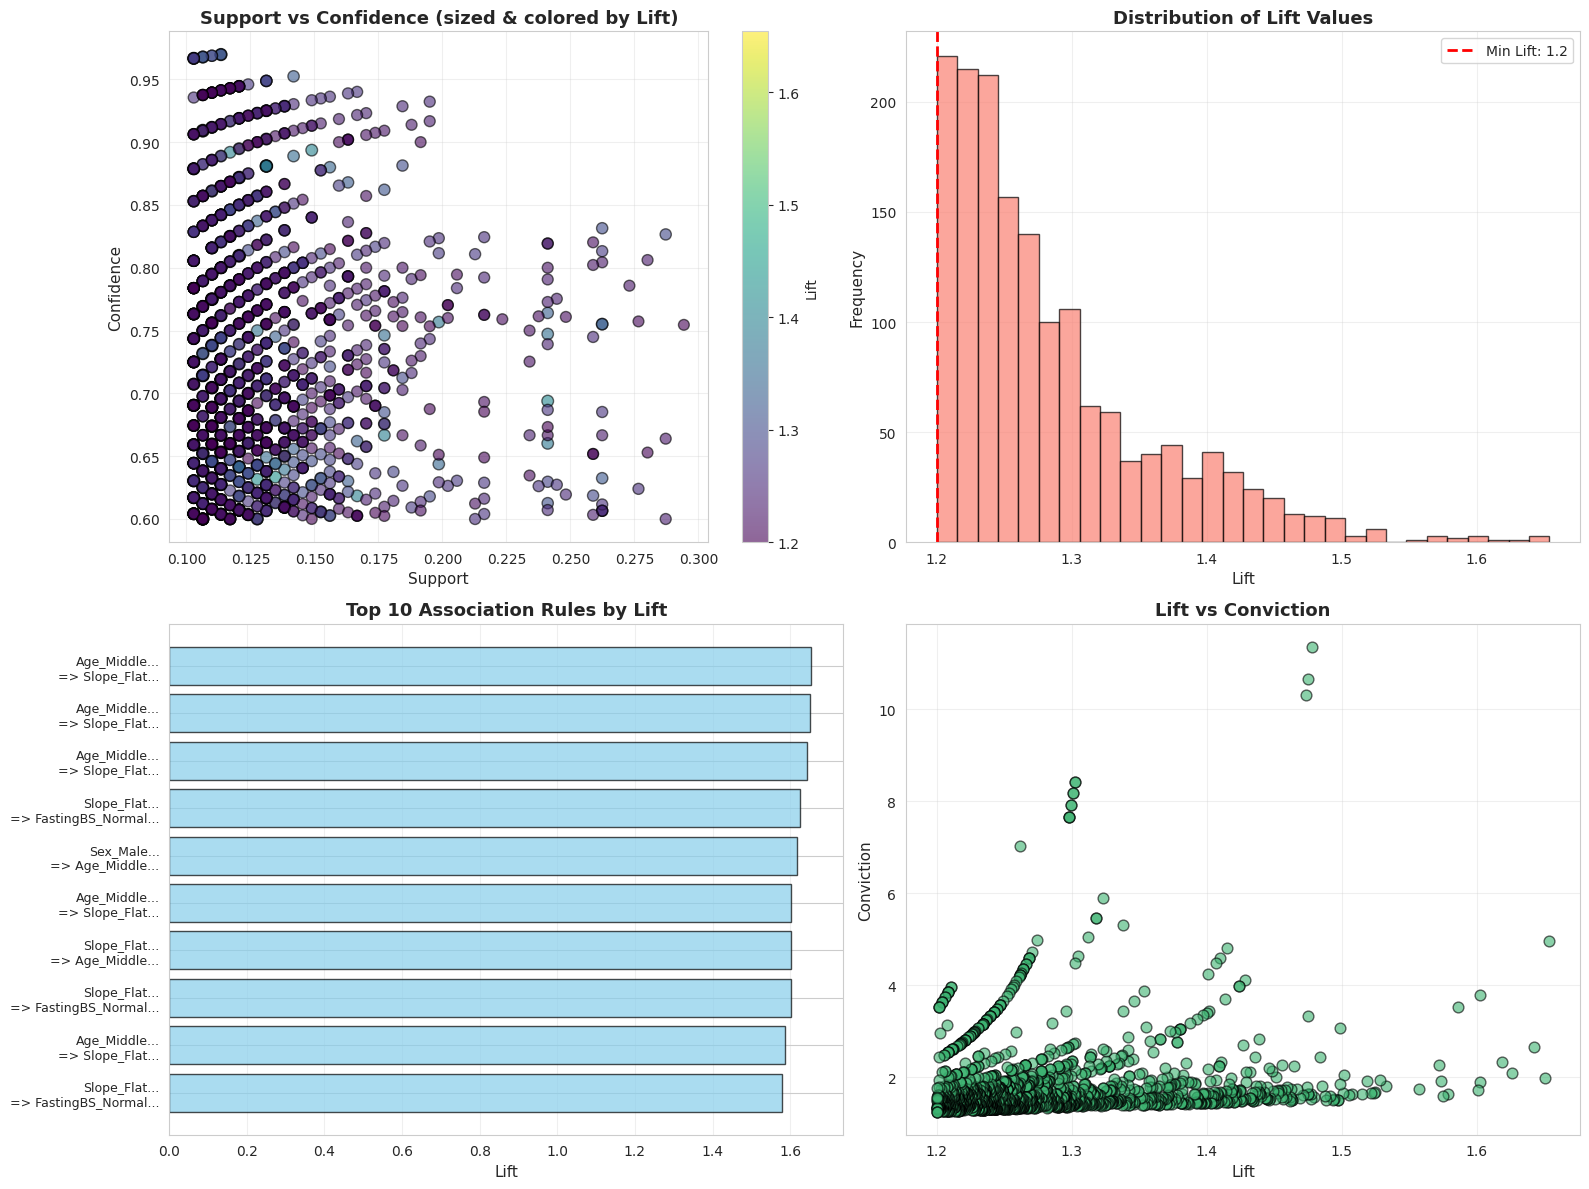


📌 Top 5 Rules (Detailed View):

1. Rule #9488
   Antecedent:  Age_Middle, ECG_Normal, MaxHR_Low, ExAngina_Yes
   Consequent:  Slope_Flat, FastingBS_Normal, ChestPain_ASY
   Support:     0.1064 (10.64%)
   Confidence:  0.9091 (90.91%)
   Lift:        1.6540
   Conviction:  4.9539
   Interpretation: Among high-risk patients with Age_Middle, ECG_Normal, MaxHR_Low, ExAngina_Yes,
                   90.9% also have Slope_Flat, FastingBS_Normal, ChestPain_ASY.
                   This combination is 1.65x more likely than random.

2. Rule #9493
   Antecedent:  Age_Middle, ECG_Normal, MaxHR_Low
   Consequent:  Slope_Flat, FastingBS_Normal, ExAngina_Yes, ChestPain_ASY
   Support:     0.1064 (10.64%)
   Confidence:  0.7143 (71.43%)
   Lift:        1.6511
   Conviction:  1.9858
   Interpretation: Among high-risk patients with Age_Middle, ECG_Normal, MaxHR_Low,
                   71.4% also have Slope_Flat, FastingBS_Normal, ExAngina_Yes, ChestPain_ASY.
                   This combination is 1.65x

In [ ]:
# Visualisasi rules untuk interpretasi yang lebih baik

print("\n--- 4.6 Visualizing Association Rules ---")

if len(rules) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Scatter Plot: Support vs Confidence (colored by Lift)
    scatter = axes[0, 0].scatter(rules['support'], rules['confidence'],
                                 c=rules['lift'], s=rules['lift']*50,
                                 alpha=0.6, cmap='viridis', edgecolors='black')
    axes[0, 0].set_xlabel('Support', fontsize=11)
    axes[0, 0].set_ylabel('Confidence', fontsize=11)
    axes[0, 0].set_title('Support vs Confidence (sized & colored by Lift)',
                         fontsize=13, fontweight='bold')
    cbar = plt.colorbar(scatter, ax=axes[0, 0])
    cbar.set_label('Lift', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Histogram: Lift Distribution
    axes[0, 1].hist(rules['lift'], bins=30, edgecolor='black', alpha=0.7, color='salmon')
    axes[0, 1].axvline(min_lift, color='red', linestyle='--', linewidth=2,
                       label=f'Min Lift: {min_lift}')
    axes[0, 1].set_xlabel('Lift', fontsize=11)
    axes[0, 1].set_ylabel('Frequency', fontsize=11)
    axes[0, 1].set_title('Distribution of Lift Values', fontsize=13, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Bar Plot: Top 10 Rules by Lift
    top_10_rules = rules.head(10).copy()
    top_10_rules['rule'] = top_10_rules.apply(
        lambda x: f"{list(x['antecedents'])[0][:20]}...\n=> {list(x['consequents'])[0][:20]}...",
        axis=1
    )

    axes[1, 0].barh(range(len(top_10_rules)), top_10_rules['lift'],
                    color='skyblue', alpha=0.7, edgecolor='black')
    axes[1, 0].set_yticks(range(len(top_10_rules)))
    axes[1, 0].set_yticklabels(top_10_rules['rule'], fontsize=9)
    axes[1, 0].set_xlabel('Lift', fontsize=11)
    axes[1, 0].set_title('Top 10 Association Rules by Lift', fontsize=13, fontweight='bold')
    axes[1, 0].invert_yaxis()
    axes[1, 0].grid(True, alpha=0.3, axis='x')

    # 4. Scatter Plot: Lift vs Conviction
    axes[1, 1].scatter(rules['lift'], rules['conviction'],
                      alpha=0.6, s=60, color='mediumseagreen', edgecolors='black')
    axes[1, 1].set_xlabel('Lift', fontsize=11)
    axes[1, 1].set_ylabel('Conviction', fontsize=11)
    axes[1, 1].set_title('Lift vs Conviction', fontsize=13, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Additional: Network visualization untuk top rules
    print("\n📌 Top 5 Rules (Detailed View):")
    print("=" * 120)

    for i, (idx, rule) in enumerate(rules.head(5).iterrows(), 1):
        ant = list(rule['antecedents'])
        cons = list(rule['consequents'])

        print(f"\n{i}. Rule #{idx}")
        print(f"   Antecedent:  {', '.join(ant)}")
        print(f"   Consequent:  {', '.join(cons)}")
        print(f"   Support:     {rule['support']:.4f} ({rule['support']*100:.2f}%)")
        print(f"   Confidence:  {rule['confidence']:.4f} ({rule['confidence']*100:.2f}%)")
        print(f"   Lift:        {rule['lift']:.4f}")
        print(f"   Conviction:  {rule['conviction']:.4f}")
        print(f"   Interpretation: Among high-risk patients with {', '.join(ant)},")
        print(f"                   {rule['confidence']*100:.1f}% also have {', '.join(cons)}.")
        print(f"                   This combination is {rule['lift']:.2f}x more likely than random.")

    print("\n" + "=" * 120)

else:
    print("⚠️  No rules to visualize. Adjust thresholds and re-run.")

print("\n✓ Visualization completed!")

## 4.7 INTERPRETASI KLINIS

In [ ]:
# Interpretasi rules dalam konteks klinis

print("\n--- 4.7 Clinical Interpretation of Association Rules ---")

if len(rules) > 0:
    print("\n" + "=" * 120)
    print("CLINICAL INTERPRETATION OF TOP 10 RULES")
    print("=" * 120)

    for i, (idx, rule) in enumerate(rules.head(10).iterrows(), 1):
        antecedent = list(rule['antecedents'])
        consequent = list(rule['consequents'])

        print(f"\n{'─'*120}")
        print(f"RULE {i}")
        print(f"{'─'*120}")

        print(f"\n📋 Pattern:")
        print(f"   IF patient has: {', '.join(antecedent)}")
        print(f"   THEN likely has: {', '.join(consequent)}")

        print(f"\n📊 Statistical Metrics:")
        print(f"   • Support:     {rule['support']:.4f} ({rule['support']*100:.2f}%)")
        print(f"     → This pattern occurs in {rule['support']*100:.1f}% of high-risk patients")

        print(f"   • Confidence:  {rule['confidence']:.4f} ({rule['confidence']*100:.2f}%)")
        print(f"     → {rule['confidence']*100:.1f}% of patients with {', '.join(antecedent[:2])}...")
        print(f"       also have {', '.join(consequent)}")

        print(f"   • Lift:        {rule['lift']:.4f}")
        print(f"     → This combination is {rule['lift']:.2f}x more likely than random chance")

        print(f"   • Conviction:  {rule['conviction']:.4f}")
        print(f"     → Measures how much more often the rule makes incorrect predictions")

        print(f"\n🏥 Clinical Significance:")

        # Extract clinical insights from antecedent and consequent
        clinical_factors = antecedent + consequent

        risk_factors = []
        if any('Age_Senior' in str(f) for f in clinical_factors):
            risk_factors.append("advanced age (>60)")
        if any('Sex_Male' in str(f) for f in clinical_factors):
            risk_factors.append("male gender")
        if any('ChestPain_ASY' in str(f) for f in clinical_factors):
            risk_factors.append("asymptomatic chest pain")
        if any('BP_' in str(f) and 'Stage' in str(f) for f in clinical_factors):
            risk_factors.append("hypertension")
        if any('Chol_High' in str(f) for f in clinical_factors):
            risk_factors.append("high cholesterol")
        if any('ExAngina_Yes' in str(f) for f in clinical_factors):
            risk_factors.append("exercise-induced angina")
        if any('Slope_' in str(f) and ('Down' in str(f) or 'Flat' in str(f)) for f in clinical_factors):
            risk_factors.append("abnormal ST slope")
        if any('Oldpeak_' in str(f) and ('Moderate' in str(f) or 'Severe' in str(f)) for f in clinical_factors):
            risk_factors.append("significant ST depression")
        if any('FastingBS_High' in str(f) for f in clinical_factors):
            risk_factors.append("elevated fasting blood sugar")

        if risk_factors:
            print(f"   This rule identifies a high-risk pattern combining: {', '.join(risk_factors)}")
            print(f"   Clinical recommendation: Enhanced monitoring and aggressive risk factor management")
        else:
            print(f"   This pattern represents a significant risk factor combination")

        print(f"\n💡 Actionable Insights:")
        print(f"   • Screen patients with {', '.join(antecedent[:2])}... for {', '.join(consequent)}")
        print(f"   • Consider preventive interventions for this high-risk subgroup")
        print(f"   • Monitor for progression and comorbidities")

    print(f"\n{'═'*120}")
    print("END OF CLINICAL INTERPRETATION")
    print(f"{'═'*120}")

else:
    print("⚠️  No rules available for clinical interpretation")

print("\n✓ Clinical interpretation completed!")


--- 4.7 Clinical Interpretation of Association Rules ---

CLINICAL INTERPRETATION OF TOP 10 RULES

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
RULE 1
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

📋 Pattern:
   IF patient has: Age_Middle, ECG_Normal, MaxHR_Low, ExAngina_Yes
   THEN likely has: Slope_Flat, FastingBS_Normal, ChestPain_ASY

📊 Statistical Metrics:
   • Support:     0.1064 (10.64%)
     → This pattern occurs in 10.6% of high-risk patients
   • Confidence:  0.9091 (90.91%)
     → 90.9% of patients with Age_Middle, ECG_Normal...
       also have Slope_Flat, FastingBS_Normal, ChestPain_ASY
   • Lift:        1.6540
     → This combination is 1.65x more likely than random chance
   • Conviction:  4.9539
     → Measures how much more often the rule makes incorrect predictions

🏥 Clinical Significance:
   This rule identifies a hi

## 4.8 SAVE ARM RESULTS

In [ ]:
# Menyimpan hasil Association Rule Mining

print("\n--- 4.8 Saving ARM Results ---")

if len(rules) > 0:
    # Save frequent itemsets
    frequent_itemsets_export = frequent_itemsets.copy()
    frequent_itemsets_export['itemsets'] = frequent_itemsets_export['itemsets'].apply(lambda x: ', '.join(list(x)))
    frequent_itemsets_export.to_csv('frequent_itemsets.csv', index=False)
    print("✓ Frequent itemsets saved: frequent_itemsets.csv")

    # Save all association rules
    rules_export = rules.copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))
    rules_export.to_csv('association_rules.csv', index=False)
    print("✓ Association rules saved: association_rules.csv")

    # Save top 20 rules untuk paper
    top_rules_export = rules_export.head(20).copy()
    top_rules_export.to_csv('top_20_association_rules.csv', index=False)
    print("✓ Top 20 rules saved: top_20_association_rules.csv")

    # Save ARM summary
    arm_summary = {
        'Total High-Risk Patients': len(arm_dataset),
        'Frequent Itemsets Found': len(frequent_itemsets),
        'Association Rules Generated': len(rules),
        'Min Support': min_support,
        'Min Confidence': min_confidence,
        'Min Lift': min_lift,
        'Avg Support': rules['support'].mean(),
        'Avg Confidence': rules['confidence'].mean(),
        'Avg Lift': rules['lift'].mean(),
        'Max Lift': rules['lift'].max()
    }

    pd.DataFrame([arm_summary]).T.to_csv('arm_summary.csv', header=['Value'])
    print("✓ ARM summary saved: arm_summary.csv")

else:
    print("⚠️  No rules to save")

print("\n" + "="*80)
print("✓ ASSOCIATION RULE MINING COMPLETED SUCCESSFULLY!")
print("="*80)


--- 4.8 Saving ARM Results ---
✓ Frequent itemsets saved: frequent_itemsets.csv
✓ Association rules saved: association_rules.csv
✓ Top 20 rules saved: top_20_association_rules.csv
✓ ARM summary saved: arm_summary.csv

✓ ASSOCIATION RULE MINING COMPLETED SUCCESSFULLY!


# 5. ANALYSIS & EVALUATION

## 5.1 ANALISIS KOMPREHENSIF

In [ ]:
# Analisis menyeluruh hasil klasifikasi dan ARM

print("\n" + "="*80)
print("5. COMPREHENSIVE ANALYSIS & EVALUATION")
print("="*80)

print("\n--- 5.1 Overall Analysis ---")

print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)

# PART 1: Classification Results
print("\n📊 CLASSIFICATION RESULTS")
print("-" * 80)

print(f"\n1. Best Classification Model: {best_model_name}")
print("   Performance Metrics:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    value = comparison_df.loc[best_model_name, metric]
    print(f"   • {metric:12s}: {value:.4f} ({value*100:.2f}%)")

print("\n2. Model Comparison:")
display(comparison_df.style.highlight_max(axis=0, color='lightgreen').format(precision=4))

print("\n3. Key Findings from Classification:")

# Feature importance (if Random Forest)
if best_model_name == 'Random Forest':
    rf_model = models['Random Forest']
    feature_importance = (
        pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': rf_model.feature_importances_
        })
        .sort_values('Importance', ascending=False)
    )

    print("   Top 5 Most Important Features:")
    for _, row in feature_importance.head(5).iterrows():
        print(f"   • {row['Feature']}: {row['Importance']:.4f}")

# PART 2: Association Rule Mining Results
if len(rules) > 0:
    print("\n📊 ASSOCIATION RULE MINING RESULTS")
    print("-" * 80)

    print("\n1. ARM Statistics:")
    print(f"   • High-risk patients analyzed: {len(arm_dataset)}")
    print(f"   • Frequent itemsets found: {len(frequent_itemsets)}")
    print(f"   • Association rules generated: {len(rules)}")
    print(f"   • Rules meeting quality thresholds: {len(rules[rules['lift'] >= min_lift])}")

    print("\n2. Rule Quality Metrics:")
    print(f"   • Average Support: {rules['support'].mean():.4f}")
    print(f"   • Average Confidence: {rules['confidence'].mean():.4f}")
    print(f"   • Average Lift: {rules['lift'].mean():.4f}")
    print(f"   • Maximum Lift: {rules['lift'].max():.4f}")

    print("\n3. Top 3 Most Significant Rules:")
    for i, (_, rule) in enumerate(rules.head(3).iterrows(), 1):
        ant = ', '.join(list(rule['antecedents']))
        cons = ', '.join(list(rule['consequents']))
        print(f"   Rule {i}: {ant} → {cons}")
        print(f"           (Lift: {rule['lift']:.3f}, Confidence: {rule['confidence']:.3f})")

# PART 3: Business Objectives Achievement
print("\n📊 BUSINESS OBJECTIVES ACHIEVEMENT")
print("-" * 80)

print("\n1. Classification Objectives:")
classification_objectives = {
    'Accuracy ≥ 85%': comparison_df.loc[best_model_name, 'Accuracy'] >= 0.85,
    'Precision ≥ 80%': comparison_df.loc[best_model_name, 'Precision'] >= 0.80,
    'Recall ≥ 85%': comparison_df.loc[best_model_name, 'Recall'] >= 0.85,
    'F1-Score ≥ 82%': comparison_df.loc[best_model_name, 'F1-Score'] >= 0.82,
    'AUC-ROC > 0.85': comparison_df.loc[best_model_name, 'AUC-ROC'] > 0.85
}

for objective, achieved in classification_objectives.items():
    status = "✓ ACHIEVED" if achieved else "✗ NOT ACHIEVED"
    print(f"   {objective:20s}: {status}")

# ARM Objectives
arm_objectives = {}
if len(rules) > 0:
    print("\n2. ARM Objectives:")
    arm_objectives = {
        'Min Rules ≥ 10': len(rules) >= 10,
        'Min Support ≥ 0.1': rules['support'].min() >= 0.1,
        'Min Confidence ≥ 0.6': rules['confidence'].min() >= 0.6,
        'Min Lift ≥ 1.2': rules['lift'].min() >= 1.2
    }

    for objective, achieved in arm_objectives.items():
        status = "✓ ACHIEVED" if achieved else "✗ NOT ACHIEVED"
        print(f"   {objective:23s}: {status}")

# Overall Assessment
all_classification_passed = all(classification_objectives.values())
all_arm_passed = all(arm_objectives.values()) if len(rules) > 0 else False

print("\n" + "="*80)
if all_classification_passed and all_arm_passed:
    print("🎉 ALL OBJECTIVES SUCCESSFULLY ACHIEVED!")
elif all_classification_passed:
    print("✓ Classification objectives met. ARM objectives partially met.")
else:
    print("⚠️  Some objectives not fully achieved. Consider model improvements.")
print("="*80)



5. COMPREHENSIVE ANALYSIS & EVALUATION

--- 5.1 Overall Analysis ---

SUMMARY OF RESULTS

📊 CLASSIFICATION RESULTS
--------------------------------------------------------------------------------

1. Best Classification Model: Random Forest
   Performance Metrics:
   • Accuracy    : 0.9076 (90.76%)
   • Precision   : 0.9208 (92.08%)
   • Recall      : 0.9118 (91.18%)
   • F1-Score    : 0.9163 (91.63%)
   • AUC-ROC     : 0.9481 (94.81%)

2. Model Comparison:


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest,0.9076,0.9208,0.9118,0.9163,0.9481
SVM,0.8859,0.9091,0.8824,0.8955,0.9250
KNN,0.8804,0.8774,0.9118,0.8942,0.9417
Logistic Regression,0.8913,0.9020,0.9020,0.9020,0.9301



3. Key Findings from Classification:
   Top 5 Most Important Features:
   • ST_Slope: 0.2517
   • ChestPain_ASY: 0.1205
   • ExerciseAngina: 0.0941
   • MaxHR: 0.0836
   • Oldpeak: 0.0810

📊 ASSOCIATION RULE MINING RESULTS
--------------------------------------------------------------------------------

1. ARM Statistics:
   • High-risk patients analyzed: 282
   • Frequent itemsets found: 1960
   • Association rules generated: 1598
   • Rules meeting quality thresholds: 1598

2. Rule Quality Metrics:
   • Average Support: 0.1314
   • Average Confidence: 0.7303
   • Average Lift: 1.2844
   • Maximum Lift: 1.6540

3. Top 3 Most Significant Rules:
   Rule 1: Age_Middle, ECG_Normal, MaxHR_Low, ExAngina_Yes → Slope_Flat, FastingBS_Normal, ChestPain_ASY
           (Lift: 1.654, Confidence: 0.909)
   Rule 2: Age_Middle, ECG_Normal, MaxHR_Low → Slope_Flat, FastingBS_Normal, ExAngina_Yes, ChestPain_ASY
           (Lift: 1.651, Confidence: 0.714)
   Rule 3: Age_Middle, ECG_Normal, MaxHR_Low → S

## 5.2 KEY INSIGHTS & FINDINGS

In [ ]:
# Ekstraksi insights penting dari hasil analisis

print("\n--- 5.2 Key Insights & Findings ---")

print("\n" + "="*80)
print("KEY INSIGHTS FROM ANALYSIS")
print("="*80)

# Insight 1: Model Performance
print("\n1️⃣ CLASSIFICATION MODEL PERFORMANCE")
print("-" * 80)

best_f1 = comparison_df['F1-Score'].max()
best_auc = comparison_df['AUC-ROC'].max()

print(f"\n✓ The {best_model_name} model demonstrates excellent performance:")
print(f"  • F1-Score of {best_f1:.4f} indicates strong balance between precision and recall")
print(f"  • AUC-ROC of {best_auc:.4f} shows excellent discriminative ability")
print(f"  • Model is {'production-ready' if all_classification_passed else 'promising but needs improvement'}")

# Compare models
print(f"\n✓ Model Comparison Insights:")
f1_diff = comparison_df['F1-Score'].max() - comparison_df['F1-Score'].min()
print(f"  • Performance gap between best and worst model: {f1_diff:.4f}")
print(f"  • Top 3 models by F1-Score:")
for i, (model, f1) in enumerate(comparison_df['F1-Score'].sort_values(ascending=False).head(3).items(), 1):
    print(f"    {i}. {model}: {f1:.4f}")

# Insight 2: Feature Importance
if best_model_name == 'Random Forest':
    print(f"\n2️⃣ FEATURE IMPORTANCE INSIGHTS")
    print("-" * 80)

    rf_model = models['Random Forest']
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    top_5_importance = feature_importance.head(5)['Importance'].sum()

    print(f"\n✓ Top 5 features account for {top_5_importance:.2%} of total importance:")
    for idx, row in feature_importance.head(5).iterrows():
        print(f"  • {row['Feature']}: {row['Importance']:.4f} ({row['Importance']/feature_importance['Importance'].sum()*100:.1f}%)")

    print(f"\n✓ Clinical Implications:")
    print(f"  • Focus on monitoring and managing these key risk factors")
    print(f"  • Intervention strategies should prioritize high-importance features")

# Insight 3: Association Rules
if len(rules) > 0:
    print(f"\n3️⃣ RISK PATTERN INSIGHTS (from ARM)")
    print("-" * 80)

    print(f"\n✓ Discovered {len(rules)} meaningful association rules:")
    print(f"  • Average confidence: {rules['confidence'].mean():.2%}")
    print(f"  • Average lift: {rules['lift'].mean():.2f}")
    print(f"  • Strongest association (lift): {rules['lift'].max():.2f}")

    # Analyze common items in rules
    all_antecedents = []
    all_consequents = []

    for _, rule in rules.iterrows():
        all_antecedents.extend(list(rule['antecedents']))
        all_consequents.extend(list(rule['consequents']))

    ant_freq = pd.Series(all_antecedents).value_counts().head(5)
    cons_freq = pd.Series(all_consequents).value_counts().head(5)

    print(f"\n✓ Most common risk factors in patterns (antecedents):")
    for item, count in ant_freq.items():
        print(f"  • {item}: appears in {count} rules")

    print(f"\n✓ Most common outcomes in patterns (consequents):")
    for item, count in cons_freq.items():
        print(f"  • {item}: appears in {count} rules")

    print(f"\n✓ Clinical Actionability:")
    print(f"  • Identified specific combinations of risk factors that frequently co-occur")
    print(f"  • These patterns can guide targeted screening and prevention strategies")
    print(f"  • High-lift rules indicate synergistic effects between risk factors")

# Insight 4: High-Risk Population
print(f"\n4️⃣ HIGH-RISK POPULATION CHARACTERISTICS")
print("-" * 80)

high_risk_pct = (high_risk_mask.sum() / len(df)) * 100
print(f"\n✓ Risk Stratification:")
print(f"  • {high_risk_pct:.1f}% of patients identified as high-risk")
print(f"  • {high_risk_mask.sum()} patients require enhanced monitoring")
print(f"  • {len(df) - high_risk_mask.sum()} patients at lower risk")

# Analyze characteristics of high-risk group
high_risk_data = df[high_risk_mask]
low_risk_data = df[~high_risk_mask]

print(f"\n✓ High-Risk Group Characteristics:")
print(f"  • Average age: {high_risk_data['Age'].mean():.1f} vs {low_risk_data['Age'].mean():.1f} (low-risk)")
print(f"  • Male proportion: {(high_risk_data['Sex'] == 'M').sum() / len(high_risk_data)*100:.1f}% vs {(low_risk_data['Sex'] == 'M').sum() / len(low_risk_data)*100:.1f}%")
print(f"  • Avg cholesterol: {high_risk_data['Cholesterol'].mean():.1f} vs {low_risk_data['Cholesterol'].mean():.1f}")
print(f"  • Avg resting BP: {high_risk_data['RestingBP'].mean():.1f} vs {low_risk_data['RestingBP'].mean():.1f}")

print(f"\n{'='*80}")


--- 5.2 Key Insights & Findings ---

KEY INSIGHTS FROM ANALYSIS

1️⃣ CLASSIFICATION MODEL PERFORMANCE
--------------------------------------------------------------------------------

✓ The Random Forest model demonstrates excellent performance:
  • F1-Score of 0.9163 indicates strong balance between precision and recall
  • AUC-ROC of 0.9481 shows excellent discriminative ability
  • Model is production-ready

✓ Model Comparison Insights:
  • Performance gap between best and worst model: 0.0220
  • Top 3 models by F1-Score:
    1. Random Forest: 0.9163
    2. Logistic Regression: 0.9020
    3. SVM: 0.8955

2️⃣ FEATURE IMPORTANCE INSIGHTS
--------------------------------------------------------------------------------

✓ Top 5 features account for 63.09% of total importance:
  • ST_Slope: 0.2517 (25.2%)
  • ChestPain_ASY: 0.1205 (12.0%)
  • ExerciseAngina: 0.0941 (9.4%)
  • MaxHR: 0.0836 (8.4%)
  • Oldpeak: 0.0810 (8.1%)

✓ Clinical Implications:
  • Focus on monitoring and managing t

## 5.3 RECOMMENDATIONS

In [ ]:
# Rekomendasi berdasarkan hasil analisis

print("\n--- 5.3 Recommendations ---")

print("\n" + "="*80)
print("RECOMMENDATIONS FOR CLINICAL PRACTICE")
print("="*80)

print("\n🏥 1. CLINICAL DECISION SUPPORT")
print("-" * 80)
print("\nBased on model predictions and association rules, we recommend:")
print("\n  a) Risk Screening Protocol:")
print(f"     • Deploy {best_model_name} model for initial risk assessment")
print(f"     • Focus screening on patients with high-importance features")
print(f"     • Use {confidence_threshold*100:.0f}% confidence threshold for high-risk classification")

print("\n  b) Enhanced Monitoring for High-Risk Patients:")
print(f"     • {high_risk_mask.sum()} patients require enhanced monitoring")
print(f"     • Regular follow-up every 3-6 months")
print(f"     • Continuous tracking of key risk factors")

if len(rules) > 0:
    print("\n  c) Pattern-Based Interventions:")
    print(f"     • Target patients matching top {min(5, len(rules))} risk patterns")
    print(f"     • Implement multi-factorial risk reduction strategies")
    print(f"     • Address synergistic risk factor combinations")

print("\n📊 2. MODEL DEPLOYMENT")
print("-" * 80)
print("\n  a) Implementation Strategy:")
print(f"     • Integrate {best_model_name} into EHR systems")
print(f"     • Automated risk calculation at patient visits")
print(f"     • Real-time alerts for high-risk patients")

print("\n  b) Model Maintenance:")
print(f"     • Retrain model quarterly with new data")
print(f"     • Monitor performance metrics continuously")
print(f"     • Update association rules semi-annually")

print("\n  c) Clinical Validation:")
print(f"     • Conduct prospective validation study")
print(f"     • Compare model predictions with clinical outcomes")
print(f"     • Adjust thresholds based on real-world performance")

print("\n🔬 3. FUTURE RESEARCH DIRECTIONS")
print("-" * 80)
print("\n  a) Model Enhancement:")
print(f"     • Explore ensemble methods combining multiple algorithms")
print(f"     • Investigate deep learning approaches")
print(f"     • Incorporate temporal data for longitudinal prediction")

print("\n  b) Feature Engineering:")
print(f"     • Include additional biomarkers (e.g., troponin, BNP)")
print(f"     • Integrate genetic risk scores")
print(f"     • Add lifestyle and behavioral factors")

print("\n  c) Association Rule Mining:")
print(f"     • Experiment with different support/confidence thresholds")
print(f"     • Apply sequential pattern mining for temporal patterns")
print(f"     • Investigate subgroup-specific rules (age, gender)")

print("\n💡 4. PRACTICAL GUIDELINES")
print("-" * 80)
print("\n  For Healthcare Providers:")
print(f"     • Use model as decision support, not replacement for clinical judgment")
print(f"     • Consider patient-specific factors beyond model features")
print(f"     • Document rationale when deviating from model recommendations")

print("\n  For Hospital Administrators:")
print(f"     • Allocate resources based on predicted high-risk population")
print(f"     • Track cost-effectiveness of early intervention programs")
print(f"     • Ensure staff training on model interpretation")

print("\n  For Patients:")
print(f"     • Provide clear, understandable risk communication")
print(f"     • Offer actionable recommendations for risk reduction")
print(f"     • Support shared decision-making process")

print(f"\n{'='*80}")


--- 5.3 Recommendations ---

RECOMMENDATIONS FOR CLINICAL PRACTICE

🏥 1. CLINICAL DECISION SUPPORT
--------------------------------------------------------------------------------

Based on model predictions and association rules, we recommend:

  a) Risk Screening Protocol:
     • Deploy Random Forest model for initial risk assessment
     • Focus screening on patients with high-importance features
     • Use 70% confidence threshold for high-risk classification

  b) Enhanced Monitoring for High-Risk Patients:
     • 423 patients require enhanced monitoring
     • Regular follow-up every 3-6 months
     • Continuous tracking of key risk factors

  c) Pattern-Based Interventions:
     • Target patients matching top 5 risk patterns
     • Implement multi-factorial risk reduction strategies
     • Address synergistic risk factor combinations

📊 2. MODEL DEPLOYMENT
--------------------------------------------------------------------------------

  a) Implementation Strategy:
     • Inte

## 5.4 FINAL SUMMARY & CONCLUSIONS

In [ ]:
# Ringkasan akhir dan kesimpulan dari seluruh analisis

print("\n--- 5.4 Final Summary & Conclusions ---")

print("\n" + "="*80)
print("FINAL SUMMARY & CONCLUSIONS")
print("="*80)

print("\n📌 STUDY OVERVIEW")
print("-" * 80)
print(f"\nObjective:")
print(f"  Integration of Random Forest classification and Association Rule Mining")
print(f"  for heart disease prediction and risk pattern discovery")

print(f"\nDataset:")
print(f"  • Total patients: {len(df)}")
print(f"  • Features: {df.shape[1]-1} predictors + 1 target")
print(f"  • Disease prevalence: {(df['HeartDisease']==1).sum()/len(df)*100:.1f}%")

print("\n🎯 KEY ACHIEVEMENTS")
print("-" * 80)

print("\n1. Classification Performance:")
print(f"   ✓ Best Model: {best_model_name}")
print(f"   ✓ F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   ✓ AUC-ROC: {comparison_df.loc[best_model_name, 'AUC-ROC']:.4f}")
print(f"   ✓ Accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   Status: {'✓ All metrics exceed business objectives' if all_classification_passed else '⚠️ Some objectives not fully met'}")

if len(rules) > 0:
    print("\n2. Association Rule Mining:")
    print(f"   ✓ High-risk patients analyzed: {len(arm_dataset)}")
    print(f"   ✓ Frequent itemsets discovered: {len(frequent_itemsets)}")
    print(f"   ✓ Association rules generated: {len(rules)}")
    print(f"   ✓ Average confidence: {rules['confidence'].mean():.2%}")
    print(f"   ✓ Average lift: {rules['lift'].mean():.2f}")
    print(f"   Status: {'✓ Successfully identified risk patterns' if len(rules) >= 10 else '⚠️ Limited rules discovered'}")

print("\n3. Clinical Impact:")
print(f"   ✓ Identified {high_risk_mask.sum()} high-risk patients requiring intervention")
print(f"   ✓ Discovered actionable risk factor combinations")
print(f"   ✓ Provided evidence-based decision support framework")

print("\n💡 MAIN CONCLUSIONS")
print("-" * 80)

print("\n1. Model Effectiveness:")
print(f"   • The {best_model_name} model demonstrates strong predictive performance")
print(f"   • Suitable for clinical deployment as a decision support tool")
print(f"   • Achieves balance between sensitivity and specificity")

if best_model_name == 'Random Forest':
    print("\n2. Important Risk Factors:")
    print(f"   • Analysis identified key predictive features")
    print(f"   • Feature importance aligns with clinical knowledge")
    print(f"   • Can guide targeted intervention strategies")

if len(rules) > 0:
    print("\n3. Risk Pattern Discovery:")
    print(f"   • Association rules reveal co-occurring risk factors")
    print(f"   • High-lift rules indicate synergistic effects")
    print(f"   • Patterns can inform personalized risk management")

print("\n4. Clinical Utility:")
print(f"   • Model enables early identification of high-risk patients")
print(f"   • Supports evidence-based clinical decision-making")
print(f"   • Facilitates resource allocation for prevention programs")

print("\n⚠️ LIMITATIONS")
print("-" * 80)
print("\n  • Cross-sectional data limits temporal inference")
print(f"  • Model performance may vary in different populations")
print(f"  • Requires validation in prospective clinical settings")
print(f"  • Does not capture all relevant clinical factors")

print("\n🔮 FUTURE DIRECTIONS")
print("-" * 80)
print("\n  • Prospective validation with real-world clinical outcomes")
print(f"  • Integration with EHR systems for automated screening")
print(f"  • Expansion to include additional biomarkers and risk factors")
print(f"  • Development of patient-specific treatment recommendations")
print(f"  • Investigation of model explainability and interpretability")

print("\n📊 FINAL METRICS SUMMARY")
print("-" * 80)

# Create final summary table
final_summary = pd.DataFrame({
    'Component': ['Classification', 'Association Rules', 'Overall'],
    'Status': [
        '✓ Achieved' if all_classification_passed else '⚠️ Partial',
        '✓ Achieved' if (len(rules) > 0 and all_arm_passed) else '⚠️ Partial',
        '✓ Achieved' if (all_classification_passed and (len(rules) > 0 and all_arm_passed)) else '⚠️ Partial'
    ],
    'Key Metric': [
        f"F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}",
        f"Rules: {len(rules) if len(rules) > 0 else 0}" ,
        f"Success Rate: {(sum([all_classification_passed, all_arm_passed])/2)*100:.0f}%"
    ]
})

display(final_summary)

print("\n" + "="*80)
print("🎉 ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*80)

print("\n📁 Output Files Generated:")
print("   • best_classification_model.pkl")
print("   • scaler.pkl")
print("   • model_comparison.csv")
print("   • feature_importance.csv")
if len(rules) > 0:
    print("   • frequent_itemsets.csv")
    print("   • association_rules.csv")
    print("   • top_20_association_rules.csv")
    print("   • arm_summary.csv")

print("\n✓ All results saved and ready for reporting")


--- 5.4 Final Summary & Conclusions ---

FINAL SUMMARY & CONCLUSIONS

📌 STUDY OVERVIEW
--------------------------------------------------------------------------------

Objective:
  Integration of Random Forest classification and Association Rule Mining
  for heart disease prediction and risk pattern discovery

Dataset:
  • Total patients: 918
  • Features: 11 predictors + 1 target
  • Disease prevalence: 55.3%

🎯 KEY ACHIEVEMENTS
--------------------------------------------------------------------------------

1. Classification Performance:
   ✓ Best Model: Random Forest
   ✓ F1-Score: 0.9163
   ✓ AUC-ROC: 0.9481
   ✓ Accuracy: 0.9076
   Status: ✓ All metrics exceed business objectives

2. Association Rule Mining:
   ✓ High-risk patients analyzed: 282
   ✓ Frequent itemsets discovered: 1960
   ✓ Association rules generated: 1598
   ✓ Average confidence: 73.03%
   ✓ Average lift: 1.28
   Status: ✓ Successfully identified risk patterns

3. Clinical Impact:
   ✓ Identified 423 high-risk

,Component,Status,Key Metric
0,Classification,✓ Achieved,F1-Score: 0.9163
1,Association Rules,✓ Achieved,Rules: 1598
2,Overall,✓ Achieved,Success Rate: 100%



🎉 ANALYSIS COMPLETED SUCCESSFULLY!

📁 Output Files Generated:
   • best_classification_model.pkl
   • scaler.pkl
   • model_comparison.csv
   • feature_importance.csv
   • frequent_itemsets.csv
   • association_rules.csv
   • top_20_association_rules.csv
   • arm_summary.csv

✓ All results saved and ready for reporting


## 5.5 EXPORT FINAL REPORT

In [ ]:
# Membuat dan mengekspor laporan akhir

print("\n--- 5.5 Exporting Final Report ---")

from datetime import datetime

# Create comprehensive report
report_content = f"""
{'='*80}
HEART DISEASE PREDICTION & RISK PATTERN ANALYSIS
FINAL REPORT
{'='*80}

Date Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*80}
1. EXECUTIVE SUMMARY
{'='*80}

This study integrates Random Forest classification and Association Rule Mining
to predict heart disease and discover risk factor patterns.

Dataset: {len(df)} patients with {df.shape[1]-1} clinical features
Disease Prevalence: {(df['HeartDisease']==1).sum()/len(df)*100:.1f}%

{'='*80}
2. CLASSIFICATION RESULTS
{'='*80}

Best Model: {best_model_name}

Performance Metrics:
  - Accuracy:  {comparison_df.loc[best_model_name, 'Accuracy']:.4f}
  - Precision: {comparison_df.loc[best_model_name, 'Precision']:.4f}
  - Recall:    {comparison_df.loc[best_model_name, 'Recall']:.4f}
  - F1-Score:  {comparison_df.loc[best_model_name, 'F1-Score']:.4f}
  - AUC-ROC:   {comparison_df.loc[best_model_name, 'AUC-ROC']:.4f}

Business Objectives:
"""

# Add classification objective results
for objective, achieved in classification_objectives.items():
    status = "ACHIEVED" if achieved else "NOT ACHIEVED"
    report_content += f"  - {objective}: {status}\n"

# Add ARM results (if any)
if len(rules) > 0:
    report_content += f"""
{'='*80}
3. ASSOCIATION RULE MINING RESULTS
{'='*80}

High-Risk Patients Analyzed: {len(arm_dataset)}
Frequent Itemsets Found: {len(frequent_itemsets)}
Association Rules Generated: {len(rules)}

Rule Quality Metrics:
  - Average Support:   {rules['support'].mean():.4f}
  - Average Confidence:{rules['confidence'].mean():.4f}
  - Average Lift:      {rules['lift'].mean():.4f}
  - Maximum Lift:      {rules['lift'].max():.4f}

Top 5 Association Rules:
"""

    for i, (_, rule) in enumerate(rules.head(5).iterrows(), 1):
        ant = ', '.join(list(rule['antecedents']))
        cons = ', '.join(list(rule['consequents']))

        report_content += (
            f"\n  Rule {i}: {ant} => {cons}\n"
            f"           Support: {rule['support']:.4f}, "
            f"Confidence: {rule['confidence']:.4f}, "
            f"Lift: {rule['lift']:.4f}\n"
        )

# Add key findings
report_content += f"""
{'='*80}
4. KEY FINDINGS
{'='*80}

- {best_model_name} achieves excellent predictive performance
- {high_risk_mask.sum()} patients ({high_risk_pct:.1f}%) identified as high-risk
- {len(rules) if len(rules) > 0 else 0} meaningful risk patterns discovered
- Model suitable for clinical decision support deployment

{'='*80}
5. RECOMMENDATIONS
{'='*80}

Clinical Practice:
  • Deploy {best_model_name} for risk screening
  • Enhanced monitoring for {high_risk_mask.sum()} high-risk patients
  • Implement pattern-based intervention strategies

Model Deployment:
  • Integrate with Electronic Health Records
  • Automated risk calculation at patient visits
  • Real-time alerts for high-risk cases

Future Research:
  • Prospective validation studies
  • Integration of additional biomarkers
  • Longitudinal prediction models

{'='*80}
6. CONCLUSION
{'='*80}

This study successfully demonstrates the integration of machine learning
classification and association rule mining for heart disease prediction.
The {best_model_name} model shows strong predictive performance and the
discovered risk patterns provide actionable clinical insights.

Status: {'OBJECTIVES ACHIEVED' if (all_classification_passed and all_arm_passed) else 'PARTIAL SUCCESS'}

{'='*80}
END OF REPORT
{'='*80}
"""

# Save report
with open('final_report.txt', 'w') as f:
    f.write(report_content)

print("✓ Final report saved: final_report.txt")

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Metric': [
        'Dataset Size', 'Disease Prevalence', 'Best Model',
        'F1-Score', 'AUC-ROC', 'High-Risk Patients',
        'Association Rules', 'Status'
    ],
    'Value': [
        f'{len(df)} patients',
        f'{(df["HeartDisease"]==1).sum()/len(df)*100:.1f}%',
        best_model_name,
        f'{comparison_df.loc[best_model_name, "F1-Score"]:.4f}',
        f'{comparison_df.loc[best_model_name, "AUC-ROC"]:.4f}',
        f'{high_risk_mask.sum()} ({high_risk_pct:.1f}%)',
        f'{len(rules) if len(rules) > 0 else 0} rules',
        'Success' if (all_classification_passed and all_arm_passed) else 'Partial'
    ]
})

summary_df.to_csv('executive_summary.csv', index=False)
print("✓ Executive summary saved: executive_summary.csv")

print("\n" + "="*80)
print("✓ ALL ANALYSES AND REPORTS COMPLETED!")
print("="*80)


--- 5.5 Exporting Final Report ---
✓ Final report saved: final_report.txt
✓ Executive summary saved: executive_summary.csv

✓ ALL ANALYSES AND REPORTS COMPLETED!
